1. select some of positive samples in test/train set
2. Inference original sample in the finetunned model and output prediction softmax value
3. Filter out samples having at least one intersect with ACSs
4. Perturbing samples by eliminating ACSs and extend sample from left and right to 500 bp, as before was
5. Inference perturbed input by the finetunned model to see how much prediction softmax value changed
6. Report changes
7. for true positives have considerable probability change, observe how attention score pattern changed


In [7]:
import os
import pandas as pd
import numpy as np
# from pyfaidx import Fasta

import torch
import transformers
import matplotlib.pyplot as plt

%matplotlib inline

/p/project1/hai_dnaori/piroozeh1/venv_dnabert2/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

data_dir="/data/OriDB_random_neg/train_dev_test_oridb"

test = pd.read_csv(os.path.join(data_dir,"test_window.tsv"), sep='\t', header=0)
print(test)

     chr    start      end                                                seq  \
0     13   363312   363811  ATGCATTACAAATTTGTATTTGATTCTATATATAGTTTCGTTATAT...   
1      4   483669   484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
2      7  1056150  1056649  CCTTGTAGTTGTCCTGCAAAGATGGGTAGGTATTTTCCTTGATATG...   
3     15   766442   766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
4      4   638559   639058  CTCTAACTAATACAAACTCCTTACTATCTAATATAACGGCTACATC...   
..   ...      ...      ...                                                ...   
125   10    18014    18513  AGTAAAACTCTTGTGTCTTTTCATCGAACGTCCATGCAGAACCACC...   
126   16   698214   698713  TAAGCTCTGAGGGGCTTAATACTGTTGGTAAGACTCCAGAAATCGT...   
127   16   339219   339718  CTGGACCGCCCGGTAAGTTCTGCTATTAACAAATTAAATAAAATTG...   
128    4  1252944  1253443  AGAGGTCATTGTTCAAAGTGAGTTGGTGAGTTTTGGTCGGATACCC...   
129    8   555958   556457  ACATAACTGAATGTTAAAATGGCATCATCAATACAGTATTACTGAT...   

     label  
0        0  
1

In [4]:
positives = test[test['label'] == 1]
positives['intersects'] = [[] for _ in range(len(positives))]
print(positives)

     chr   start     end                                                seq  \
1      4  483669  484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
3     15  766442  766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
6     15  337119  337618  AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...   
7      7  607176  607675  AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...   
12     6  256090  256589  GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...   
..   ...     ...     ...                                                ...   
114    4   15368   15867  AAAAAATTAGAGATTCATTGAATCTCTAATTTATTTAAAGTTTATA...   
115    8  359441  359940  CATCTCCTTATACTGTATATGATAATATACTGGTGGTGAATGACAG...   
121   10  336811  337310  CTAATGTAATGACAGATTCCACTGCTATCCGATACGAAATAATGGA...   
122   16  842595  843094  TGGCTGAGAGGAATTCTAAGATTTCTAATGTGGAGAGGTATACTCT...   
129    8  555958  556457  ACATAACTGAATGTTAAAATGGCATCATCAATACAGTATTACTGAT...   

     label intersects  
1        1         []  
3  

/tmp/ipykernel_9579/2508721946.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positives['intersects'] = [[] for _ in range(len(positives))]


In [ ]:
# Load ACS motifs locations
bed_columns = ['chromosome', 'start', 'end', 'name', 'score', 'strand']
intersects = pd.read_csv("/p/project1/hai_dnaori/motifs_homer1.bed",sep='\t',header=None, names=bed_columns)
# intersects['chromosome'] = intersects['chromosome'].str.replace('chr', '')
intersects

,chromosome,start,end,name,score,strand
0,chr1,750,766,1-ASTTCCTCTT,14.800111,-
1,chr1,1467,1483,1-ASTTCCTCTT,7.055921,-
2,chr1,1685,1701,1-ASTTCCTCTT,8.812530,+
3,chr1,1736,1752,1-ASTTCCTCTT,11.132563,+
4,chr1,2168,2184,1-ASTTCCTCTT,10.569181,+
...,...,...,...,...,...,...
12623,chr16,942385,942401,1-ASTTCCTCTT,11.433004,+
12624,chr16,942400,942416,1-ASTTCCTCTT,8.626760,+
12625,chr16,942431,942447,1-ASTTCCTCTT,14.727791,+
12626,chr16,947887,947903,1-ASTTCCTCTT,14.707010,-


In [6]:

for index, sample in positives.iterrows():
    acs_filterd= intersects[intersects['chromosome'] == 'chr'+ str(sample['chr'])]
    acslist=[]
    for i, row in acs_filterd.iterrows():   
        if (row['start']>= sample['start'] and row['end'] <= sample['end']):
                sample['intersects'].append((row['start'],row['end']))
    
    

In [7]:
Pos_acs = positives[positives['intersects'].apply(lambda x: len(x) > 0)]
print(Pos_acs.head(2))

   chr   start     end                                                seq  \
1    4  483669  484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
3   15  766442  766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   

   label                                         intersects  
1      1                                 [(484024, 484040)]  
3      1  [(766508, 766524), (766689, 766705), (766782, ...  


In [8]:
def merge_intervals(intervals):
    """Merge overlapping or contiguous intervals."""
    if not intervals:
        return intervals

    # Sort intervals by start position
    intervals.sort(key=lambda x: x[0])
    merged = [intervals[0]]

    for current in intervals[1:]:
        prev = merged[-1]
        # If current interval overlaps or touches the previous, merge them
        if current[0] <= prev[1]:
            merged[-1] = (prev[0], max(prev[1], current[1]))
        else:
            merged.append(current)
    return merged

def remove_intersects(row):
    seq_start = row['start']
    seq_end = row['end']
    seq = row['seq']
    updated_seq = seq
    intersects = row['intersects']
    
    # Merge overlaps in intersects
    merged_intersects = merge_intervals(intersects)
    
    offset = 0
    removed_lengths = []
    for (start, end) in merged_intersects:
        # Convert start and end to indices relative to the sequence
        rel_start = start - seq_start - offset
        rel_end = end - seq_start - offset
        
        if 0 <= rel_start < len(updated_seq) and 0 <= rel_end <= len(updated_seq):
            updated_seq = updated_seq[:rel_start] + updated_seq[rel_end:]  # Remove the range from seq
            removed_lengths.append(rel_end - rel_start)
            offset += rel_end - rel_start
    
    row['updated_seq'] = updated_seq
    row['removed_lengths'] = sum(removed_lengths)  # Store total removed length
    return row
# Sample DataFrame


df = pd.DataFrame(Pos_acs)
# Apply the function to modify sequences and track removed lengths
df = df.apply(remove_intersects, axis=1)
print(df.head())


    chr   start     end                                                seq  \
1     4  483669  484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
3    15  766442  766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
6    15  337119  337618  AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...   
7     7  607176  607675  AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...   
12    6  256090  256589  GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...   

    label                                         intersects  \
1       1                                 [(484024, 484040)]   
3       1  [(766508, 766524), (766689, 766705), (766782, ...   
6       1               [(337385, 337401), (337487, 337503)]   
7       1  [(607253, 607269), (607373, 607389), (607440, ...   
12      1                                 [(256372, 256388)]   

                                          updated_seq  removed_lengths  
1   TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...               16  


In [9]:
maxlen=df.loc[df['removed_lengths'].idxmax()]
print(maxlen)
print(len(maxlen['updated_seq']))
maxlen['intersects']

chr                                                               16
start                                                         633839
end                                                           634338
seq                TTACTTTCATGGAACACTTAGTAAAAATAACTTAGAAAGGTCGTCT...
label                                                              1
intersects         [(633926, 633942), (633980, 633996), (633989, ...
updated_seq        TTACTTTCATGGAACACTTAGTAAAAATAACTTAGAAAGGTCGTCT...
removed_lengths                                                   89
Name: 112, dtype: object
411


[(633926, 633942),
 (633980, 633996),
 (633989, 634005),
 (634029, 634045),
 (634049, 634065),
 (634303, 634319)]

In [10]:
sequence_data = Fasta(f"/p/project1/hai_dnaori/sgd_data/S288C_reference_sequence_R64-3-1_20210421.fsa")
for idx, row in df.iterrows():
    # Access chromosome, start, and end for each row
    chr_id = f"chr{row['chr']}" 
    chrom_seq = sequence_data[chr_id]
    start = row["start"]
    end = row["end"]
    ex= row['removed_lengths']//2
    
    
    new_start = max(0, start - ex)
    new_end = min(len(chrom_seq), end + ex)
    left_seq=chrom_seq[new_start :start].seq
    right_seq=chrom_seq[end:new_end].seq
    df.at[idx, "ex_seq"] = left_seq+df.at[idx, "updated_seq"]+right_seq
print(len(df.iloc[5]['seq'])) 
print(len(df.iloc[5]['updated_seq'])) 
print(len(df.iloc[5]['ex_seq'])) 
df.iloc[5]
output_file = os.path.join(os.getcwd(), "test_Perturbed.csv")
df.to_csv(output_file, index=False)

500
436
500


In [9]:
data_dir="/p/project/hai_dnaori/piroozeh1/DNABERT_2/notebooks"

df = pd.read_csv(os.path.join(data_dir,"test_Perturbed_ACS.csv"))
print(df.head(5))

   chr   start     end                                                seq  \
0    4  483669  484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
1   15  766442  766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
2   15  337119  337618  AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...   
3    7  607176  607675  AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...   
4    6  256090  256589  GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...   

   label                                         intersects  \
0      1                                 [(484024, 484040)]   
1      1  [(766508, 766524), (766689, 766705), (766782, ...   
2      1               [(337385, 337401), (337487, 337503)]   
3      1  [(607253, 607269), (607373, 607389), (607440, ...   
4      1                                 [(256372, 256388)]   

                                         updated_seq  removed_lengths  \
0  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...               16   
1  CAGTTTACA

In [10]:
def inference_model( model_path, sequence):
    model_path = model_path
    config = transformers.BertConfig.from_pretrained(
                model_path,
                num_labels=2
        )
    config.output_attentions = True
    model = transformers.AutoModelForSequenceClassification.from_pretrained(model_path, config=config, from_tf=False,trust_remote_code=True)
    
    tokenizer = transformers.AutoTokenizer.from_pretrained(
        model_path,
        model_max_length=125,
        padding_side="right",
        use_fast=True,
        trust_remote_code=True   
    )
    
    inputs = tokenizer(sequence, return_tensors="pt")
  
    input_ids = inputs['input_ids']
    output = model(input_ids)
   
    logits = output.logits
    pred=logits.detach().numpy()
    softmax = torch.nn.Softmax(dim=1)
    prob=softmax(torch.tensor(pred)).numpy()

    input_id_list = input_ids[0].tolist() # Batch index 0
    decoded_text = tokenizer.decode(input_id_list, skip_special_tokens=False)
    tokens = decoded_text.split()
    attention = output.attentions
    attention_scores=attention[-1].detach().numpy()
    avg_attention_scores = np.mean(attention_scores, axis=(1, 2))
    flat_attention_scores = avg_attention_scores.flatten()
    bp_attention = []
    special_tokens = ["[CLS]", "[SEP]", "[PAD]"]
    total_token_length = 0
    non_special_token_count = 0
    for token, score in zip(tokens, flat_attention_scores):
        if token not in special_tokens:
            total_token_length += len(token)
            non_special_token_count += 1
        # For each base pair in the token, assign the same attention score
            for bp in token:
                bp_attention.append(score)
    average_token_length = total_token_length / non_special_token_count 
    return prob, bp_attention, average_token_length

    

In [14]:
def visualize(atten1, atten3, original_s, original_e, start, ACS_ranges, seq):
   
    
    x = range(len(atten1))
    e=int(original_e - start)
    s=int(original_s - start)
    plt.figure(figsize=(12, 4))
    plt.plot(x, atten1, label='Original Sequence',linestyle='-', marker='o', markersize=2)
    plt.plot(x, atten3, label='Perturbed Sequence ',linestyle='-', marker='s', markersize=2)
    
    plt.axvline(x=s, color='red', linestyle='--', label='Origin Range')
    plt.axvline(x=e, color='red', linestyle='--')


    # Validate ACS_ranges
   

    for index, item in enumerate(ACS_ranges):
        # if isinstance(item, (list, tuple)) and len(item) == 2:
            s = int(item[0] - start)
            e = int(item[1] - start)
            if index==0:
                plt.axvspan(s, e, color='yellow', alpha=0.3, label='ACS Range')
            else:
                plt.axvspan(s, e, color='yellow', alpha=0.3)
            print(seq[s:e+1])
        # else:
        #     print(f"Skipping invalid ACS_range item: {item}")

    # Add labels, title, and legend
    plt.title("Attention Scores Comparison")
    plt.xlabel("Position")
    plt.ylabel("Attention Score")
    plt.legend()
    plt.grid(True)
    plt.show()

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  0
total len of removed ACSs:  16
original:  [[0.00616455 0.99383545]]
removed:  [[0.9722639  0.02773614]]
extended:  [[0.99139696 0.00860303]]
original token len:  4.808
removed token len:  4.745
extendedtoken len:  4.762
chr                                                                4
start                                                         483669
end                                                           484168
seq                TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...
label                                                              1
intersects                                        [(484024, 484040)]
updated_seq        TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...
removed_lengths                                                   16
ex_seq             TCTTACTTTTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAG...
Name: 0, dtype: object
    chr   start     end        name  length
53    4  483846  484091  417,00 ARS     246
ACATAAATATAAAAAAA


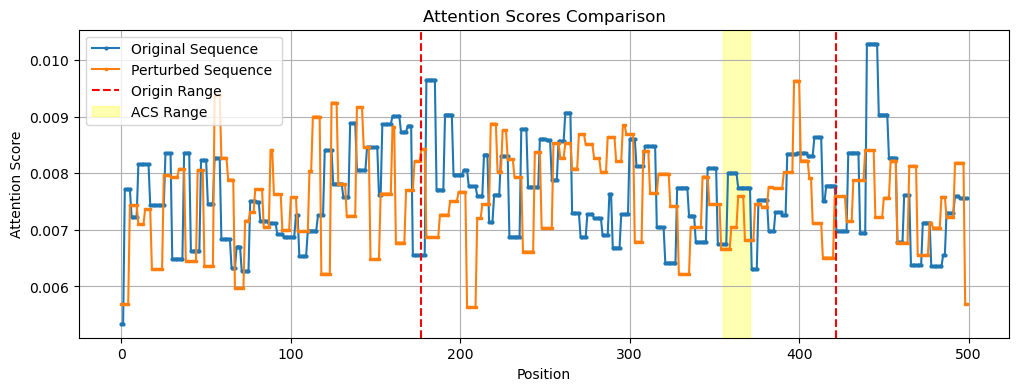

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  8
total len of removed ACSs:  16
original:  [[0.00583335 0.9941666 ]]
removed:  [[0.0055967  0.99440324]]
extended:  [[0.97802275 0.02197718]]
original token len:  5.155
removed token len:  5.149
extendedtoken len:  5.102
chr                                                                7
start                                                         231509
end                                                           232008
seq                TGTTCATTAATTTTTATGAACTTGACTTCATCCTACTTGGATTACA...
label                                                              1
intersects                                        [(231929, 231945)]
updated_seq        TGTTCATTAATTTTTATGAACTTGACTTCATCCTACTTGGATTACA...
removed_lengths                                                   16
ex_seq             AATGACTTTGTTCATTAATTTTTATGAACTTGACTTCATCCTACTT...
Name: 8, dtype: object
     chr   start     end        name  length
113    7  231909  231984  711,00 ARS      76
TCAATTAATGTTTTGAG


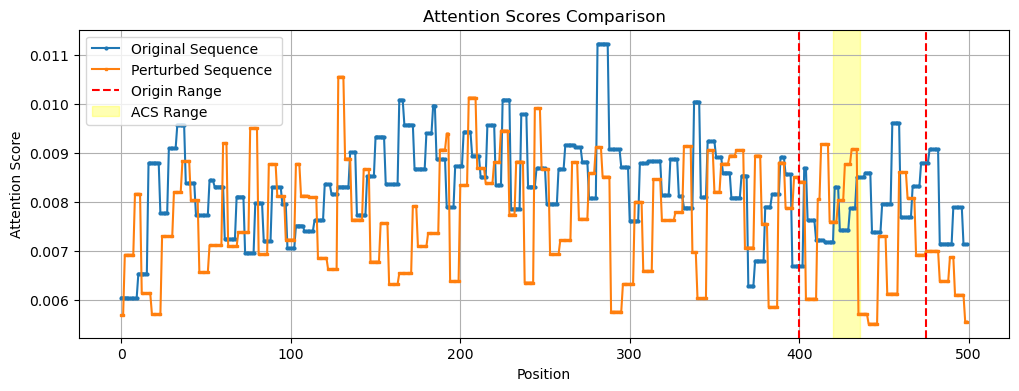

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  12
total len of removed ACSs:  32
original:  [[0.00788358 0.9921164 ]]
removed:  [[0.9939306 0.0060694]]
extended:  [[0.99268943 0.00731059]]
original token len:  5.051
removed token len:  5.032
extendedtoken len:  5.102
chr                                                                6
start                                                         135585
end                                                           136084
seq                TTGTACATTCAATATAATTTTTTTTTATTGTTCTTGAAATGAATAC...
label                                                              1
intersects                      [(135598, 135614), (136034, 136050)]
updated_seq        TTGTACATTCAATGTTCTTGAAATGAATACGTCTGGAAGTGTAGCG...
removed_lengths                                                   32
ex_seq             TTATTATATTTAGGGTTTGTACATTCAATGTTCTTGAAATGAATAC...
Name: 12, dtype: object
     chr   start     end        name  length
100    6  135979  136080  605,00 ARS     102
ATAATTTTTTTTTATTG
AACAAAACGTAATT

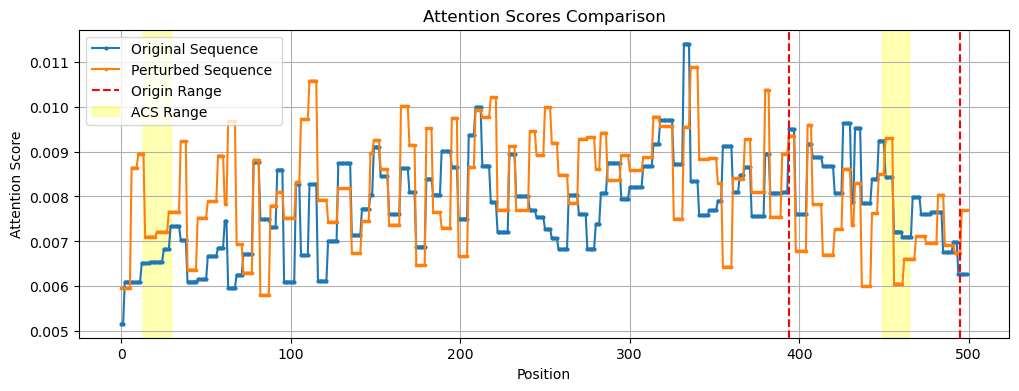

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  16
total len of removed ACSs:  32
original:  [[0.00569275 0.9943072 ]]
removed:  [[0.00627503 0.993725  ]]
extended:  [[0.99390864 0.00609137]]
original token len:  4.762
removed token len:  4.68
extendedtoken len:  4.673
chr                                                                4
start                                                         462286
end                                                           462785
seq                GGTGGGACAGGTGAACTTTTGGATTGGAACTCGATTTCTGACTGGG...
label                                                              1
intersects                      [(462534, 462550), (462593, 462609)]
updated_seq        GGTGGGACAGGTGAACTTTTGGATTGGAACTCGATTTCTGACTGGG...
removed_lengths                                                   32
ex_seq             TTTGATTCAGAAGCAGGGTGGGACAGGTGAACTTTTGGATTGGAAC...
Name: 16, dtype: object
    chr   start     end        name  length
52    4  462430  462700  416,00 ARS     271
TTTATTTAAGTATTGTT
ATCTAAACATAAAAT

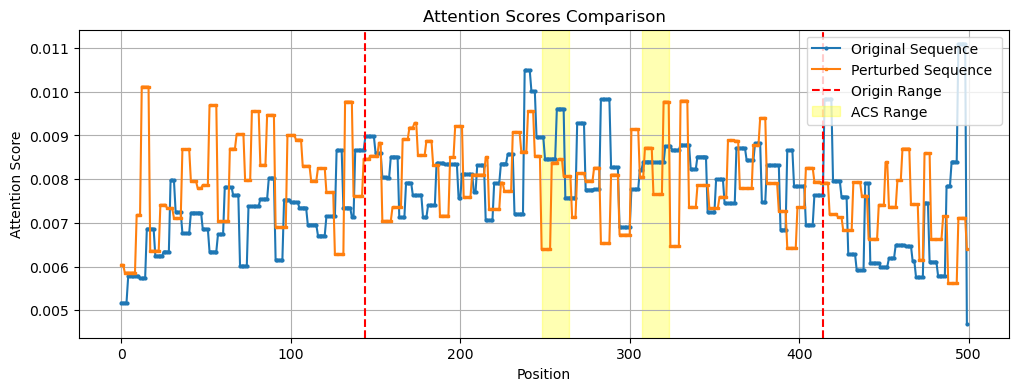

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  29
total len of removed ACSs:  16
original:  [[0.00685996 0.99314004]]
removed:  [[0.02008894 0.9799111 ]]
extended:  [[0.61495334 0.38504666]]
original token len:  5.0
removed token len:  4.99
extendedtoken len:  4.95
chr                                                               10
start                                                         298469
end                                                           298968
seq                TCCAAGAAAAGTTCGTCCTTCTTTGAGTTCATTATCTGATCTTGTT...
label                                                              1
intersects                                        [(298853, 298869)]
updated_seq        TCCAAGAAAAGTTCGTCCTTCTTTGAGTTCATTATCTGATCTTGTT...
removed_lengths                                                   16
ex_seq             ATGACCTTTCCAAGAAAAGTTCGTCCTTCTTTGAGTTCATTATCTG...
Name: 29, dtype: object
     chr   start     end         name  length
172   10  298471  298952  1010,00 ARS     482
TAGTAAAAAAAAATAAT


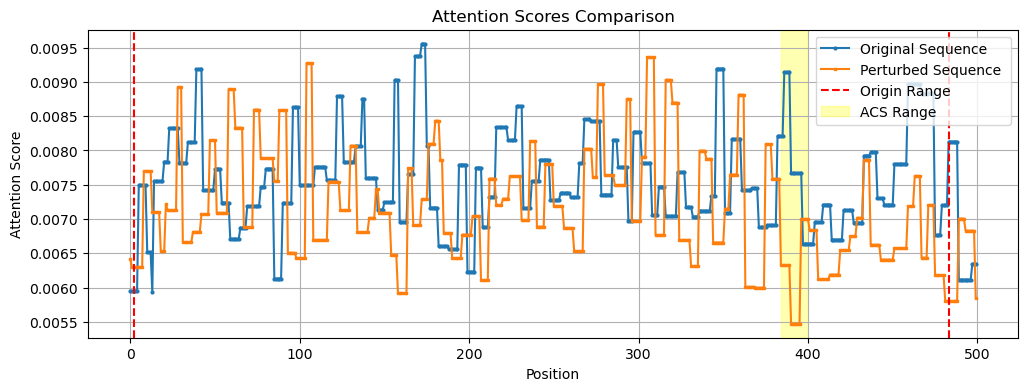

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  40
total len of removed ACSs:  32
original:  [[0.00585406 0.9941459 ]]
removed:  [[0.00562022 0.9943798 ]]
extended:  [[0.9932388  0.00676114]]
original token len:  5.102
removed token len:  5.087
extendedtoken len:  5.102
chr                                                               14
start                                                         498928
end                                                           499427
seq                TACAGTTGACATGATCCGACTCAAATGTTAATGTTCTTGAGGTTCT...
label                                                              1
intersects                      [(499040, 499056), (499301, 499317)]
updated_seq        TACAGTTGACATGATCCGACTCAAATGTTAATGTTCTTGAGGTTCT...
removed_lengths                                                   32
ex_seq             TTAATATTCAGTTCTTTACAGTTGACATGATCCGACTCAAATGTTA...
Name: 40, dtype: object
     chr   start     end         name  length
270   14  498987  499232  1420,00 ARS     246
TTTCTTTATGTTTAGCT
TATTTTCATG

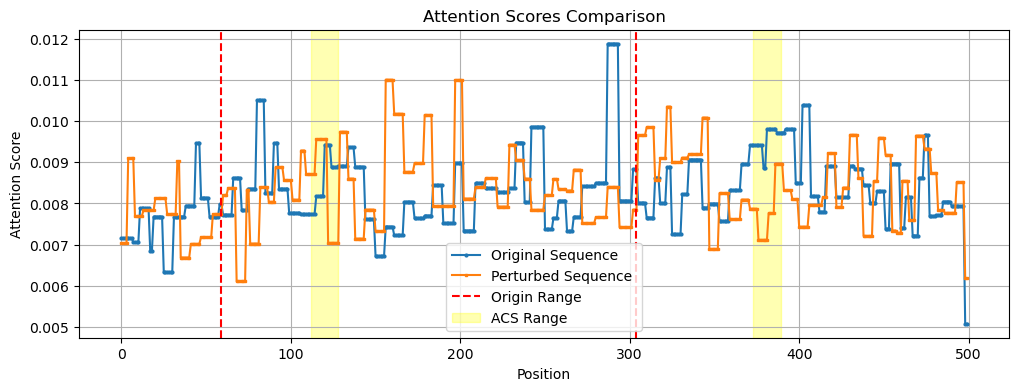

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


In [ ]:
# visualize true positives that changed to negative after perturbation
import ast

model_path = "/data/OriDB_random_neg/train_dev_test_oridb/DNABERT2/model2"
original_origin=pd.read_csv("/data/yeast_oridbLess500.csv") # Load actuall origin ranges before extension
list_index=[]
for index, row in df.iterrows():
     
    prob, atten, avrg_token_len=inference_model( model_path, row["seq"])
    prob_removed, atten_rmv, avrg_token_len2=inference_model( model_path, row["updated_seq"])
    prob_extended, atten_ex, avrg_token_len3=inference_model( model_path, row["ex_seq"])
    
    if ((prob[0,1] > 0.5) and ((prob_removed[0,1] < 0.5) or (prob_extended[0,1] < 0.5))): # true positives that changed to negative after perturbation
        list_index.append(index)
        print("seq index: ", index)
        print("total len of removed ACSs: ", row["removed_lengths"])
        print("original: ", prob)
        print("removed: ", prob_removed)
        print("extended: ", prob_extended)
        print("original token len: ", round(avrg_token_len,3))
        print("removed token len: ", round(avrg_token_len2,3))
        print("extendedtoken len: ", round(avrg_token_len3,3))
        matching_rows = original_origin[(original_origin['chr'] == row['chr']) & (original_origin['start'] >= row['start']) & (original_origin['end'] <= row['end'])]
        print(row)
        print(matching_rows)
        if not matching_rows.empty:
            origin_start=matching_rows['start'].values[0]
            origin_end=matching_rows['end'].values[0]
            intersects = row['intersects']
            list_of_tuples = ast.literal_eval(intersects)
            # print(type(list_of_tuples[0]))
        visualize(atten, atten_ex, origin_start, origin_end, row['start'], list_of_tuples, row['seq'])


/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  1
total len of removed ACSs:  48
original:  [[0.00542861 0.9945714 ]]
removed:  [[0.00542242 0.9945775 ]]
extended:  [[0.00541701 0.99458295]]
original token len:  5.155
removed token len:  5.136
extendedtoken len:  5.102
chr                                                               15
start                                                         766442
end                                                           766941
seq                CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...
label                                                              1
intersects         [(766508, 766524), (766689, 766705), (766782, ...
updated_seq        CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...
removed_lengths                                                   48
ex_seq             AACTCTAGAAGCCCGAGTAATGACCAGTTTACAAGAATCACAACAA...
Name: 1, dtype: object
     chr   start     end         name  length
297   15  766617  766862  1523,00 ARS     246
AAAAAAATATGACAAAC
GTATTTTACGTT

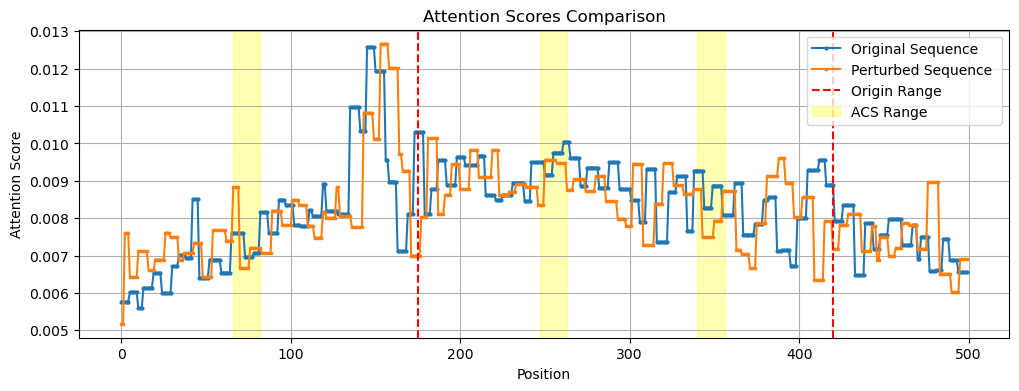

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  2
total len of removed ACSs:  32
original:  [[0.00539115 0.9946089 ]]
removed:  [[0.00539752 0.9946025 ]]
extended:  [[0.00542934 0.9945707 ]]
original token len:  4.95
removed token len:  4.875
extendedtoken len:  4.95
chr                                                               15
start                                                         337119
end                                                           337618
seq                AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...
label                                                              1
intersects                      [(337385, 337401), (337487, 337503)]
updated_seq        AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...
removed_lengths                                                   32
ex_seq             GCGGTAGGGAAGAGCAAAGAACCAGTGCAGGATATATATTATTTCC...
Name: 2, dtype: object
     chr   start     end         name  length
287   15  337279  337528  1513,00 ARS     250
TATTTTAGTATTTATTT
AAAATAACAAAAAA

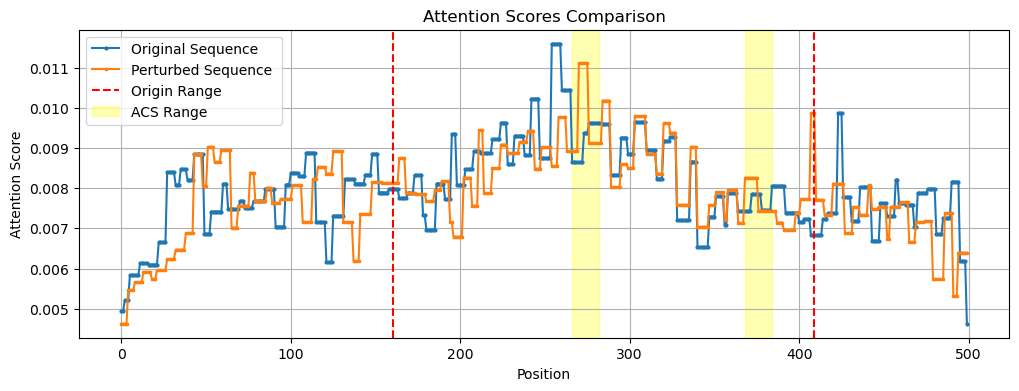

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  3
total len of removed ACSs:  78
original:  [[0.00538507 0.9946149 ]]
removed:  [[0.00542998 0.99456996]]
extended:  [[0.00544809 0.99455196]]
original token len:  5.0
removed token len:  4.851
extendedtoken len:  4.902
chr                                                                7
start                                                         607176
end                                                           607675
seq                AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...
label                                                              1
intersects         [(607253, 607269), (607373, 607389), (607440, ...
updated_seq        AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...
removed_lengths                                                   78
ex_seq             CATTGATGAAAACCATTCGTTCTTTCTGGTCGTAATACAAAATAGA...
Name: 3, dtype: object
     chr   start     end      name  length
123    7  607176  607619  ARS724.5     444
TTTAGTGATGTTTTGTT
CTATTTTACATTTATAT
AG

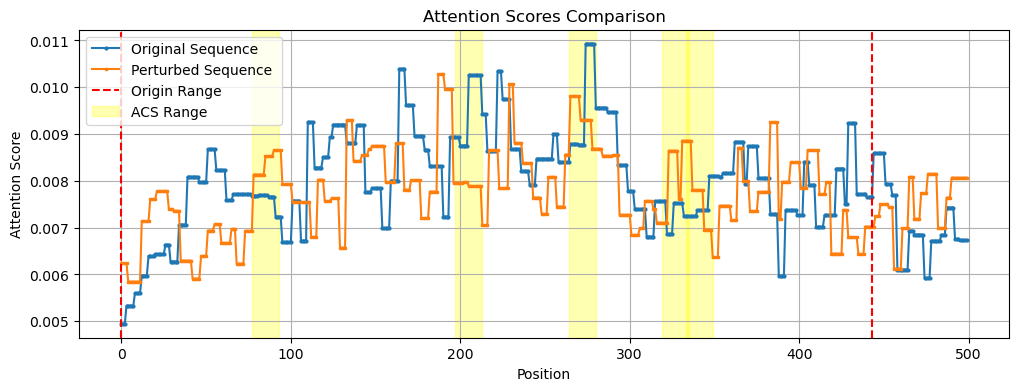

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  4
total len of removed ACSs:  16
original:  [[0.00546037 0.9945397 ]]
removed:  [[0.00555605 0.99444395]]
extended:  [[0.00567989 0.99432003]]
original token len:  5.102
removed token len:  5.095
extendedtoken len:  4.95
chr                                                                6
start                                                         256090
end                                                           256589
seq                GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...
label                                                              1
intersects                                        [(256372, 256388)]
updated_seq        GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...
removed_lengths                                                   16
ex_seq             ACAACTGGGCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGT...
Name: 4, dtype: object
     chr   start     end        name  length
105    6  256263  256418  609,00 ARS     156
GAAAAAACATAAAAAAA


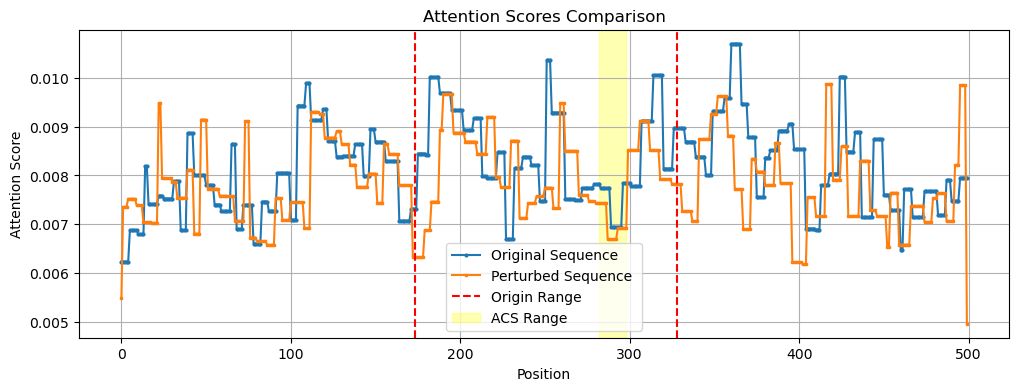

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  5
total len of removed ACSs:  64
original:  [[0.00537954 0.99462044]]
removed:  [[0.00537844 0.9946215 ]]
extended:  [[0.00541586 0.99458414]]
original token len:  5.319
removed token len:  5.19
extendedtoken len:  5.208
chr                                                                2
start                                                         622494
end                                                           622993
seq                AGCCAAACTGAAAATTTCCGTTCACGATATTTGAATCTAGTGTTAG...
label                                                              1
intersects         [(622686, 622702), (622758, 622774), (622851, ...
updated_seq        AGCCAAACTGAAAATTTCCGTTCACGATATTTGAATCTAGTGTTAG...
removed_lengths                                                   64
ex_seq             AGACTGATTCACAAGTCAGTAACATAATCCAAAGCCAAACTGAAAA...
Name: 5, dtype: object
    chr   start     end        name  length
19    2  622625  622894  220,00 ARS     270
TAATAAAAATAAATAAG
TTTATTTATATTTTTCT

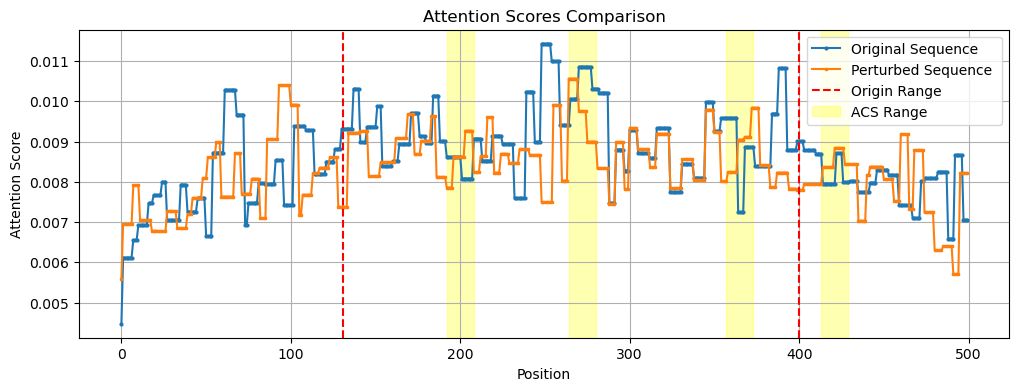

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  6
total len of removed ACSs:  32
original:  [[0.00543092 0.99456906]]
removed:  [[0.0054249 0.994575 ]]
extended:  [[0.00541276 0.9945872 ]]
original token len:  5.155
removed token len:  5.032
extendedtoken len:  5.051
chr                                                                6
start                                                         199107
end                                                           199606
seq                CGCACTCTAACTGGCATTTTAAAGAAAAAGGGATAAATGCAATGTT...
label                                                              1
intersects                      [(199413, 199429), (199468, 199484)]
updated_seq        CGCACTCTAACTGGCATTTTAAAGAAAAAGGGATAAATGCAATGTT...
removed_lengths                                                   32
ex_seq             TGTATATAGCATTTACCGCACTCTAACTGGCATTTTAAAGAAAAAG...
Name: 6, dtype: object
     chr   start     end        name  length
102    6  199382  199493  607,00 ARS     112
CTTGTTTATATTTAGTT
ACCAAAAAAAAAATAC

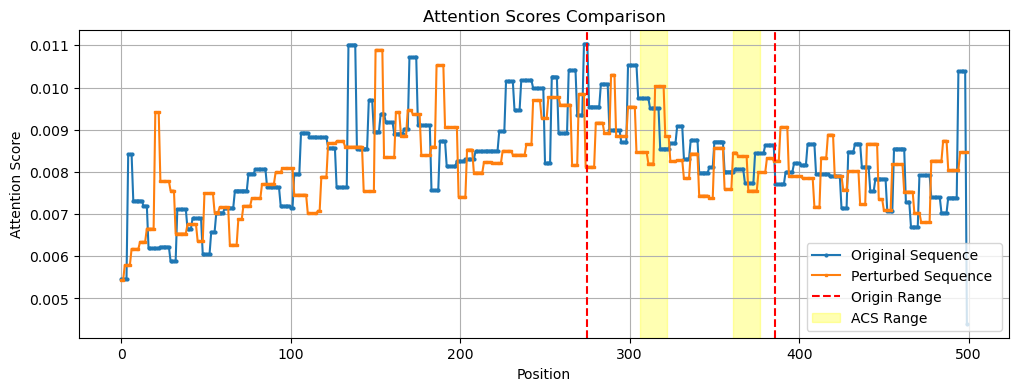

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  7
total len of removed ACSs:  50
original:  [[0.00546875 0.99453133]]
removed:  [[0.00548254 0.9945175 ]]
extended:  [[0.00541379 0.9945862 ]]
original token len:  4.95
removed token len:  4.945
extendedtoken len:  4.95
chr                                                               11
start                                                          98190
end                                                            98689
seq                GACGGAGGGGGTGGGAAAAGGCTGAATGCAACCATTGTCACTAAGA...
label                                                              1
intersects         [(98350, 98366), (98361, 98377), (98373, 98389...
updated_seq        GACGGAGGGGGTGGGAAAAGGCTGAATGCAACCATTGTCACTAAGA...
removed_lengths                                                   50
ex_seq             TTTAACCACGACTTTCGCAAGAGAGGACGGAGGGGGTGGGAAAAGG...
Name: 7, dtype: object
     chr  start    end       name  length
185   11  98329  98568  ARS1104.5     240
TTTTTTTATATTTTTTT
TTTTTTTACAATTTTTT
TTTT

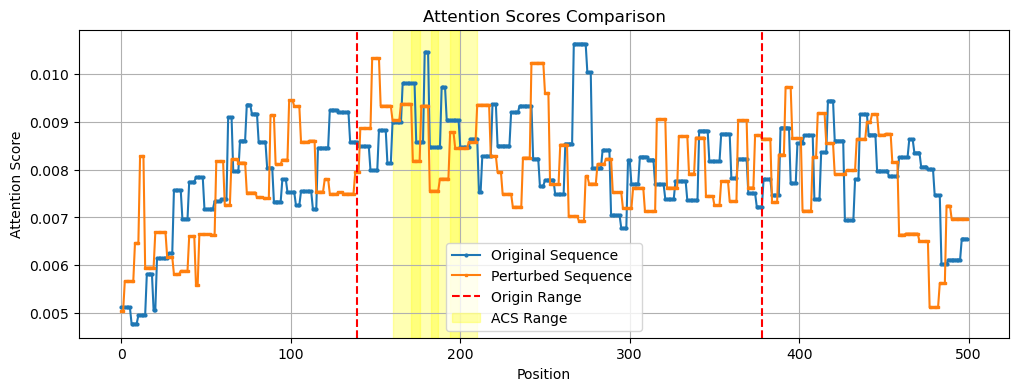

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  9
total len of removed ACSs:  16
original:  [[0.00545429 0.9945457 ]]
removed:  [[0.00545281 0.99454725]]
extended:  [[0.005432 0.994568]]
original token len:  4.902
removed token len:  4.889
extendedtoken len:  4.854
chr                                                               11
start                                                         444560
end                                                           445059
seq                AACAGATGAAAATAAAGAGGAAGAAAGTATTAAAGATGCACCAAAG...
label                                                              1
intersects                                        [(444651, 444667)]
updated_seq        AACAGATGAAAATAAAGAGGAAGAAAGTATTAAAGATGCACCAAAG...
removed_lengths                                                   16
ex_seq             AACTGGTAAACAGATGAAAATAAAGAGGAAGAAAGTATTAAAGATG...
Name: 9, dtype: object
     chr   start     end       name  length
195   11  444561  445028  ARS1113.5     468
AACAAAAAGGAAAAAGT


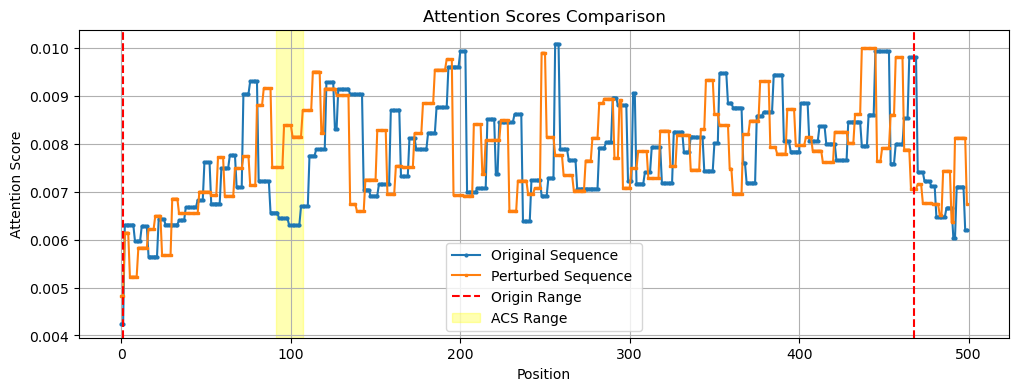

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  10
total len of removed ACSs:  48
original:  [[0.00546362 0.9945364 ]]
removed:  [[0.0054626 0.9945374]]
extended:  [[0.00544574 0.9945543 ]]
original token len:  5.155
removed token len:  5.022
extendedtoken len:  5.102
chr                                                               14
start                                                         560913
end                                                           561412
seq                AGAGTAATCGCAAACTATATTGAAGTTGGCAAAGGCACATGATCCA...
label                                                              1
intersects         [(561170, 561186), (561281, 561297), (561315, ...
updated_seq        AGAGTAATCGCAAACTATATTGAAGTTGGCAAAGGCACATGATCCA...
removed_lengths                                                   48
ex_seq             AAAGCATCAAATGATTACTTAAAAAGAGTAATCGCAAACTATATTG...
Name: 10, dtype: object
     chr   start     end         name  length
272   14  561106  561384  1422,00 ARS     279
AAGAAAAAGTAAATTCT
GTTTTTTATTTT

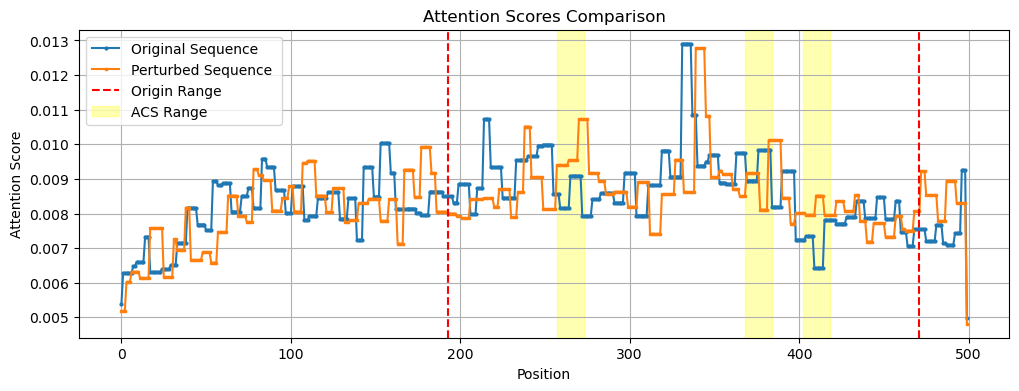

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  11
total len of removed ACSs:  32
original:  [[0.00548495 0.99451506]]
removed:  [[0.00548692 0.99451303]]
extended:  [[0.00547448 0.99452555]]
original token len:  5.0
removed token len:  4.926
extendedtoken len:  4.854
chr                                                               13
start                                                         554359
end                                                           554858
seq                CCATAGACGGAAGCATTAAGGATATTAAGTGATCAAAGATACTAGA...
label                                                              1
intersects                      [(554685, 554701), (554724, 554740)]
updated_seq        CCATAGACGGAAGCATTAAGGATATTAAGTGATCAAAGATACTAGA...
removed_lengths                                                   32
ex_seq             TGAAAAGTTTCAGTACCCATAGACGGAAGCATTAAGGATATTAAGT...
Name: 11, dtype: object
     chr   start     end         name  length
246   13  554392  554750  1322,00 ARS     359
ATAAAAAAAGAAATAAT
TGGAAAAAATAA

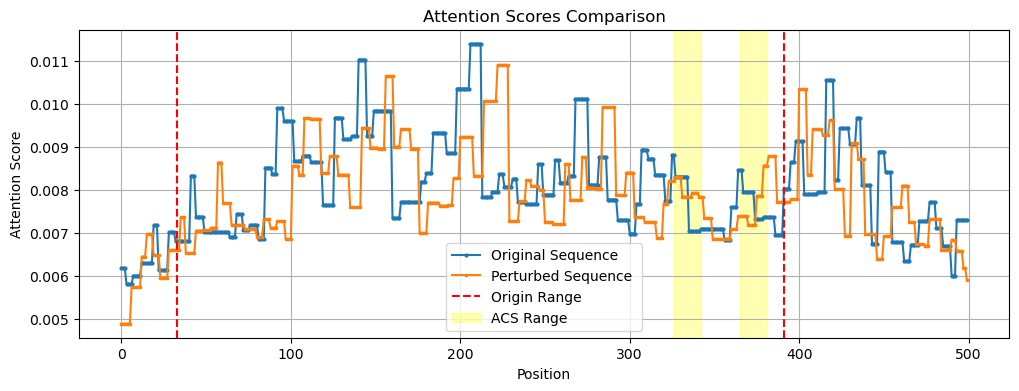

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  13
total len of removed ACSs:  32
original:  [[0.0054572  0.99454284]]
removed:  [[0.00544023 0.9945597 ]]
extended:  [[0.00545006 0.99454993]]
original token len:  5.051
removed token len:  4.875
extendedtoken len:  5.0
chr                                                               16
start                                                          73009
end                                                            73508
seq                AGTACACTGGTCAGGAAATGGTGCTTTTGCGAGGAGAATGTGTGTG...
label                                                              1
intersects                          [(73095, 73111), (73292, 73308)]
updated_seq        AGTACACTGGTCAGGAAATGGTGCTTTTGCGAGGAGAATGTGTGTG...
removed_lengths                                                   32
ex_seq             GCTGTGACGCCATAAAAGTACACTGGTCAGGAAATGGTGCTTTTGC...
Name: 13, dtype: object
     chr  start    end         name  length
305   16  73038  73283  1605,00 ARS     246
TGTTTTTTTGTTTTTTT
TTATAAATATATATAT

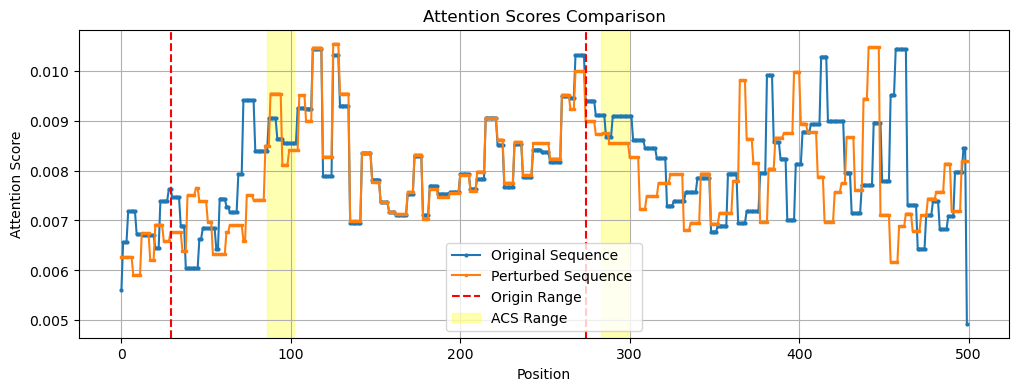

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  14
total len of removed ACSs:  80
original:  [[0.00540835 0.99459165]]
removed:  [[0.00540407 0.99459594]]
extended:  [[0.00539656 0.99460346]]
original token len:  5.102
removed token len:  5.06
extendedtoken len:  5.102
chr                                                                4
start                                                         748222
end                                                           748721
seq                AGACGAAATAAGAAGTACAAGAAAATGGAATCCCTCTCAAAATTAT...
label                                                              1
intersects         [(748345, 748361), (748463, 748479), (748521, ...
updated_seq        AGACGAAATAAGAAGTACAAGAAAATGGAATCCCTCTCAAAATTAT...
removed_lengths                                                   80
ex_seq             GGAGAGAAATTGGAATATTAGGATTCCTGGTTATTCCGCAAGACGA...
Name: 14, dtype: object
    chr   start     end      name  length
59    4  748384  748630  ARS422.5     247
TACAAAAAAATAATTAT
TTAATTAATATTTTGTA
A

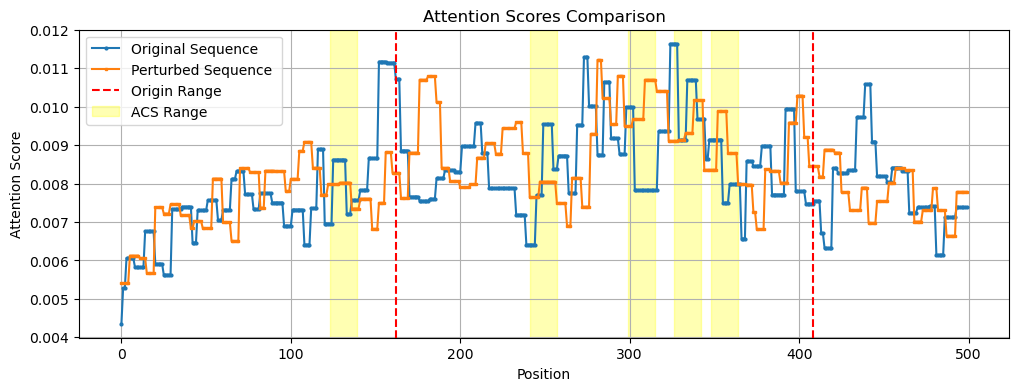

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  15
total len of removed ACSs:  32
original:  [[0.00540285 0.9945971 ]]
removed:  [[0.00542241 0.99457765]]
extended:  [[0.00543306 0.9945669 ]]
original token len:  5.155
removed token len:  5.087
extendedtoken len:  5.0
chr                                                                7
start                                                         484766
end                                                           485265
seq                TCCATAGTTGTTTTATCTTATTCTTGGCATTGATCTGCTTATTAAA...
label                                                              1
intersects                      [(484943, 484959), (485095, 485111)]
updated_seq        TCCATAGTTGTTTTATCTTATTCTTGGCATTGATCTGCTTATTAAA...
removed_lengths                                                   32
ex_seq             ATATTTACATCAGTCTTCCATAGTTGTTTTATCTTATTCTTGGCAT...
Name: 15, dtype: object
     chr   start     end        name  length
119    7  484932  485160  719,00 ARS     229
TACAAAATAAATATTTG
GGCAAAACATAAAT

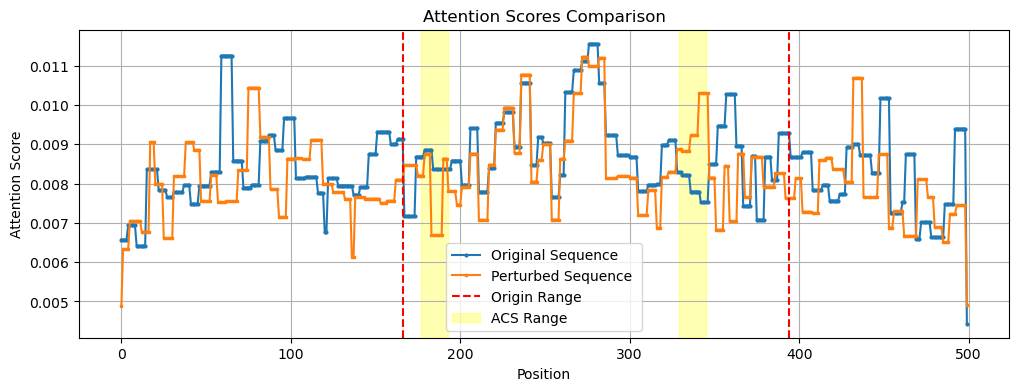

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  17
total len of removed ACSs:  48
original:  [[0.00541289 0.99458706]]
removed:  [[0.00541837 0.99458164]]
extended:  [[0.0054136  0.99458635]]
original token len:  5.051
removed token len:  5.079
extendedtoken len:  5.0
chr                                                                4
start                                                         407982
end                                                           408481
seq                GAGGACTTTTCAGTTTGAATTTGAGATATGTTGTGGAAGTTTCCCA...
label                                                              1
intersects         [(408134, 408150), (408164, 408180), (408276, ...
updated_seq        GAGGACTTTTCAGTTTGAATTTGAGATATGTTGTGGAAGTTTCCCA...
removed_lengths                                                   48
ex_seq             CGGAGTTTCGAATAAAAGACACTGGAGGACTTTTCAGTTTGAATTT...
Name: 17, dtype: object
    chr   start     end        name  length
50    4  408070  408312  414,00 ARS     243
TTATATTATATTTAGCG
AAAAAAACAAAAAAAA

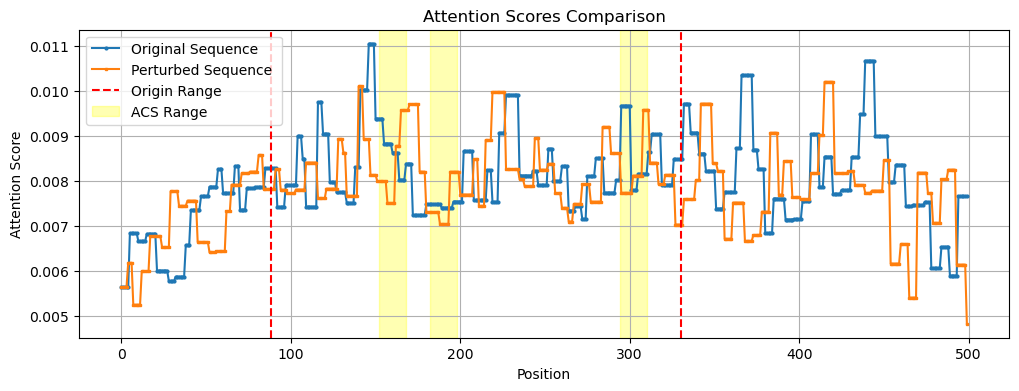

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  18
total len of removed ACSs:  16
original:  [[0.00541397 0.994586  ]]
removed:  [[0.0054045  0.99459547]]
extended:  [[0.00539128 0.99460864]]
original token len:  5.051
removed token len:  4.939
extendedtoken len:  4.902
chr                                                                4
start                                                         235710
end                                                           236209
seq                GAAAATAGGCCAATACCGACAATTAAGCCTTTTAATTTTAGTAAAG...
label                                                              1
intersects                                        [(236051, 236067)]
updated_seq        GAAAATAGGCCAATACCGACAATTAAGCCTTTTAATTTTAGTAAAG...
removed_lengths                                                   16
ex_seq             TAACAAGGGAAAATAGGCCAATACCGACAATTAAGCCTTTTAATTT...
Name: 18, dtype: object
    chr   start     end      name  length
46    4  235935  236184  ARS409.5     250
AAATAAATATAAAAAGG


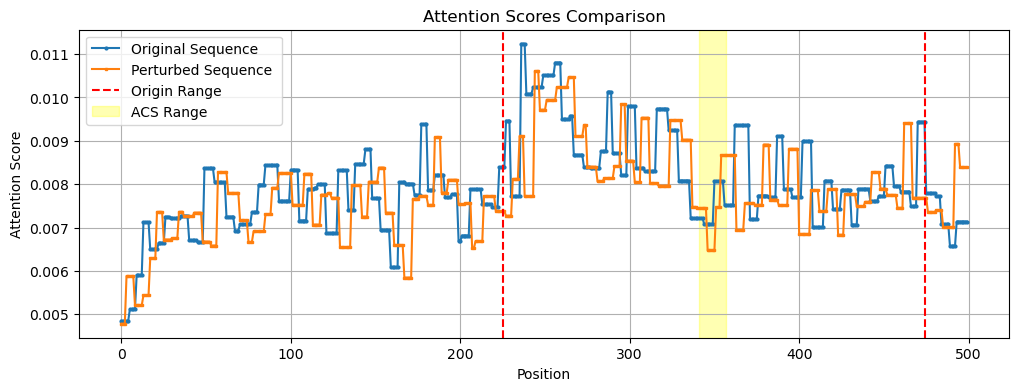

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  19
total len of removed ACSs:  32
original:  [[0.00540455 0.99459547]]
removed:  [[0.00541198 0.994588  ]]
extended:  [[0.00539425 0.9946057 ]]
original token len:  5.051
removed token len:  5.032
extendedtoken len:  5.102
chr                                                               14
start                                                         126488
end                                                           126987
seq                GCGTTCTTTGGAAGCGAGTGCAGCCGATGAAAGCGATGAAGATGAA...
label                                                              1
intersects                      [(126682, 126698), (126780, 126796)]
updated_seq        GCGTTCTTTGGAAGCGAGTGCAGCCGATGAAAGCGATGAAGATGAA...
removed_lengths                                                   32
ex_seq             AAAAGAATCTACAAAGGCGTTCTTTGGAAGCGAGTGCAGCCGATGA...
Name: 19, dtype: object
     chr   start     end         name  length
261   14  126488  126981  1410,00 ARS     494
GACATAATATTAAAACA
CACATAAAAT

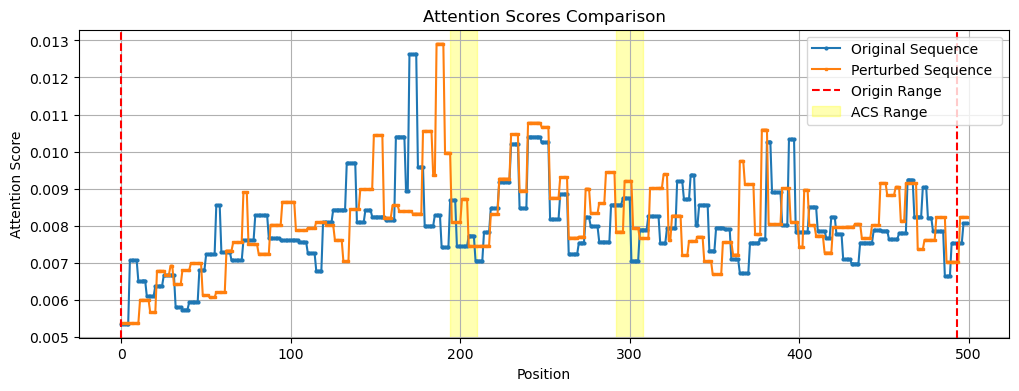

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  20
total len of removed ACSs:  32
original:  [[0.00544304 0.994557  ]]
removed:  [[0.00542316 0.9945768 ]]
extended:  [[0.00543937 0.99456066]]
original token len:  5.051
removed token len:  4.926
extendedtoken len:  5.0
chr                                                                7
start                                                         715109
end                                                           715608
seq                TTTCTTCTTATCTCAAAATGAAATTACCGTTTGCAATCAACACCGG...
label                                                              1
intersects                      [(715314, 715330), (715345, 715361)]
updated_seq        TTTCTTCTTATCTCAAAATGAAATTACCGTTTGCAATCAACACCGG...
removed_lengths                                                   32
ex_seq             ATTTTCGCCGCTATTTTTTCTTCTTATCTCAAAATGAAATTACCGT...
Name: 20, dtype: object
     chr   start     end        name  length
126    7  715273  715556  728,00 ARS     284
TTTGTTTATATTTTGTT
TTGAAGATATAAAC

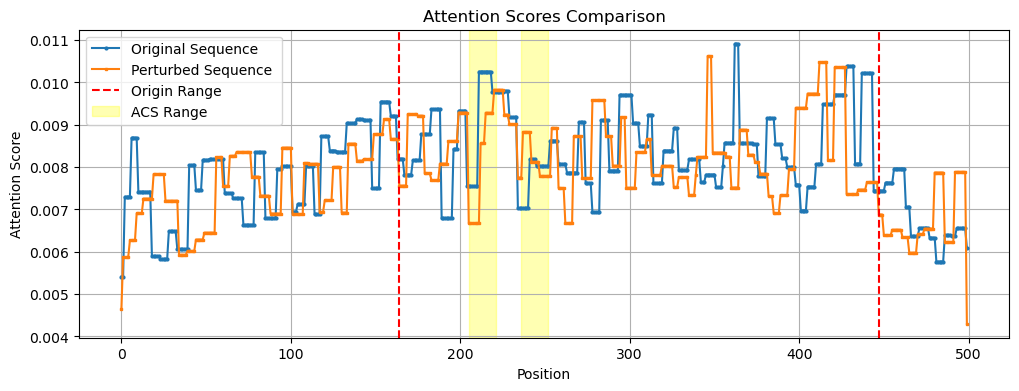

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  21
total len of removed ACSs:  32
original:  [[0.00543748 0.99456257]]
removed:  [[0.00543142 0.9945686 ]]
extended:  [[0.00542182 0.99457824]]
original token len:  5.208
removed token len:  5.2
extendedtoken len:  5.155
chr                                                                2
start                                                         237464
end                                                           237963
seq                GCATTTTCTAAACTTGTAGTTTATGTGCTTTATAGTTAATGATCAC...
label                                                              1
intersects                      [(237858, 237874), (237875, 237891)]
updated_seq        GCATTTTCTAAACTTGTAGTTTATGTGCTTTATAGTTAATGATCAC...
removed_lengths                                                   32
ex_seq             AACAAAAGATCTTGGGGCATTTTCTAAACTTGTAGTTTATGTGCTT...
Name: 21, dtype: object
    chr   start     end        name  length
12    2  237644  237879  208,00 ARS     236
AACTAAAAGTAAAAAGT
TAGAAATCATAAATAA

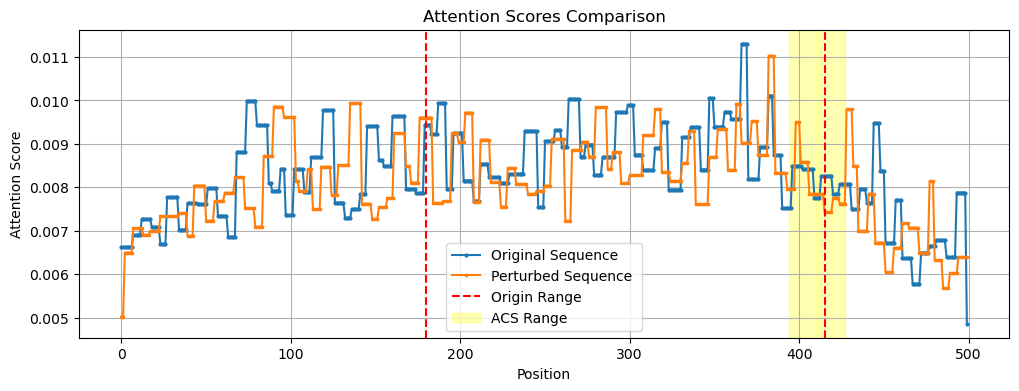

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  22
total len of removed ACSs:  16
original:  [[0.00547018 0.9945298 ]]
removed:  [[0.00547322 0.9945268 ]]
extended:  [[0.00546044 0.99453956]]
original token len:  4.902
removed token len:  4.889
extendedtoken len:  4.902
chr                                                                8
start                                                         447524
end                                                           448023
seq                GTCAGTCATAAAGCAGGAGGTCGAACGACTAGGCAACGATGTTTTT...
label                                                              1
intersects                                        [(447779, 447795)]
updated_seq        GTCAGTCATAAAGCAGGAGGTCGAACGACTAGGCAACGATGTTTTT...
removed_lengths                                                   16
ex_seq             GCGGTTTGGTCAGTCATAAAGCAGGAGGTCGAACGACTAGGCAACG...
Name: 22, dtype: object
     chr   start     end        name  length
146    8  447619  447853  820,00 ARS     235
CACAAAACATAAACATA


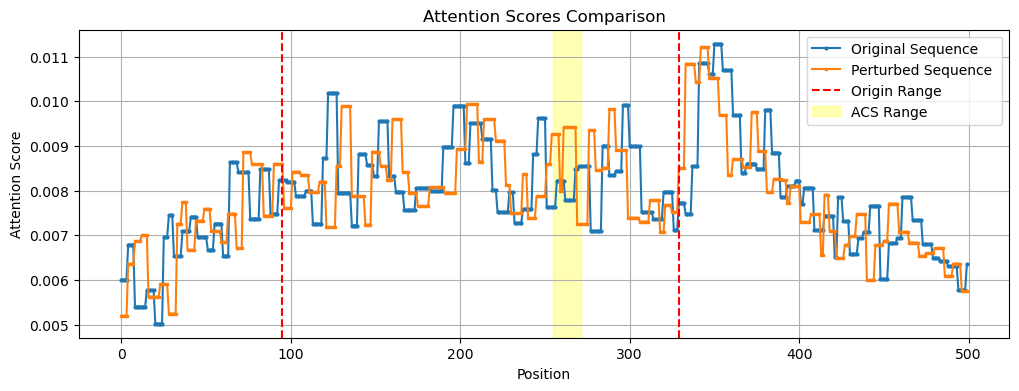

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  23
total len of removed ACSs:  16
original:  [[0.00550593 0.994494  ]]
removed:  [[0.00551822 0.9944818 ]]
extended:  [[0.00547994 0.9945201 ]]
original token len:  4.717
removed token len:  4.745
extendedtoken len:  4.717
chr                                                               16
start                                                         880682
end                                                           881181
seq                GGATTGTCAAGACACTCCGGTATTACTCGAGCCCGTAATACAACAG...
label                                                              1
intersects                                        [(880911, 880927)]
updated_seq        GGATTGTCAAGACACTCCGGTATTACTCGAGCCCGTAATACAACAG...
removed_lengths                                                   16
ex_seq             TATATTAGGGATTGTCAAGACACTCCGGTATTACTCGAGCCCGTAA...
Name: 23, dtype: object
     chr   start     end         name  length
323   16  880854  881102  1630,00 ARS     249
ATATTTTATGTTTAGGT


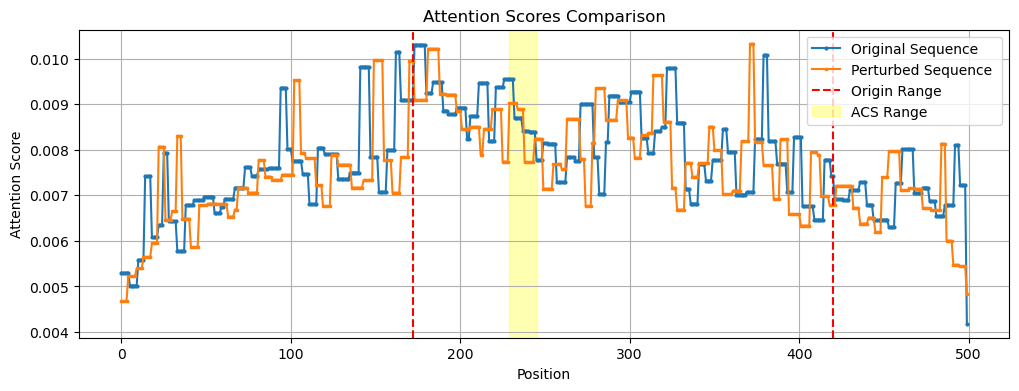

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  24
total len of removed ACSs:  32
original:  [[0.00540798 0.994592  ]]
removed:  [[0.00544324 0.9945568 ]]
extended:  [[0.00549107 0.9945089 ]]
original token len:  5.051
removed token len:  4.979
extendedtoken len:  4.95
chr                                                               16
start                                                         695396
end                                                           695895
seq                AAAATGTCTCAATGCAGCTTTGGCTGCTGCGGAACTTATCCGCTTT...
label                                                              1
intersects                      [(695470, 695486), (695608, 695624)]
updated_seq        AAAATGTCTCAATGCAGCTTTGGCTGCTGCGGAACTTATCCGCTTT...
removed_lengths                                                   32
ex_seq             GTGATGTGTATGCGAAAAAATGTCTCAATGCAGCTTTGGCTGCTGC...
Name: 24, dtype: object
     chr   start     end         name  length
318   16  695432  695681  1625,00 ARS     250
AATTTTTATATTTGGTT
CAGAAAATTAA

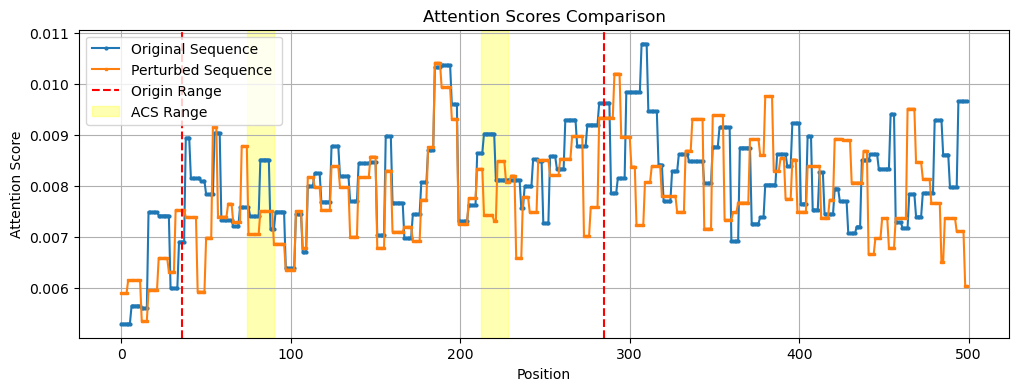

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  25
total len of removed ACSs:  62
original:  [[0.00542588 0.9945741 ]]
removed:  [[0.00542763 0.99457234]]
extended:  [[0.00541347 0.99458647]]
original token len:  5.263
removed token len:  5.093
extendedtoken len:  5.0
chr                                                               10
start                                                          99300
end                                                            99799
seq                TACTACTGGAATTTGTCCAAGAACATTTATAGGTTTGTTGGCTCTA...
label                                                              1
intersects         [(99498, 99514), (99512, 99528), (99577, 99593...
updated_seq        TACTACTGGAATTTGTCCAAGAACATTTATAGGTTTGTTGGCTCTA...
removed_lengths                                                   62
ex_seq             GGTTTATTCTCTGGTAACACCGATACTAAATTACTACTGGAATTTG...
Name: 25, dtype: object
     chr  start    end         name  length
169   10  99359  99796  1006,00 ARS     438
TTTTTTAATTTTTTTTT
TTTTTTAATTTTTTTT

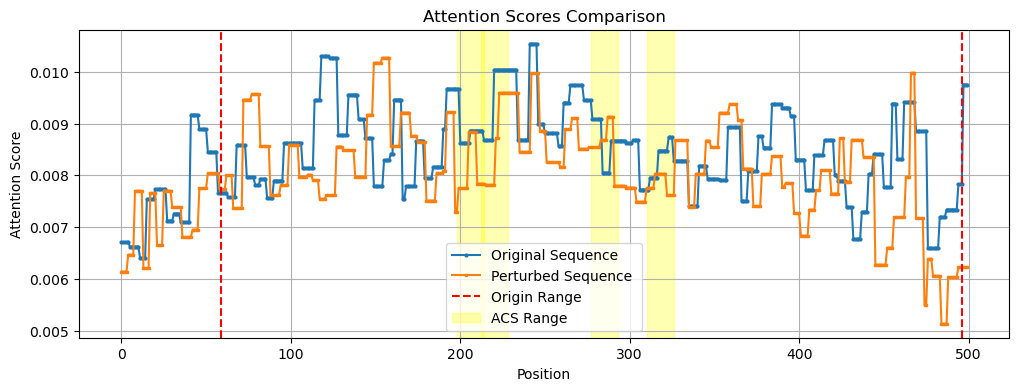

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  26
total len of removed ACSs:  48
original:  [[0.00553476 0.9944653 ]]
removed:  [[0.00555707 0.9944429 ]]
extended:  [[0.00551551 0.9944845 ]]
original token len:  4.95
removed token len:  4.913
extendedtoken len:  4.902
chr                                                               14
start                                                         195801
end                                                           196300
seq                CAGATCAGCCCCTCGACCTGCCCACGGGTTTGAAGGAGGCGTATAG...
label                                                              1
intersects         [(196152, 196168), (196210, 196226), (196249, ...
updated_seq        CAGATCAGCCCCTCGACCTGCCCACGGGTTTGAAGGAGGCGTATAG...
removed_lengths                                                   48
ex_seq             ACCCACAATAGTGAGTCTGTACGCCAGATCAGCCCCTCGACCTGCC...
Name: 26, dtype: object
     chr   start     end         name  length
263   14  196055  196291  1412,00 ARS     237
TTTTTTTTTTTTTTTTT
GGCTAAAAGTT

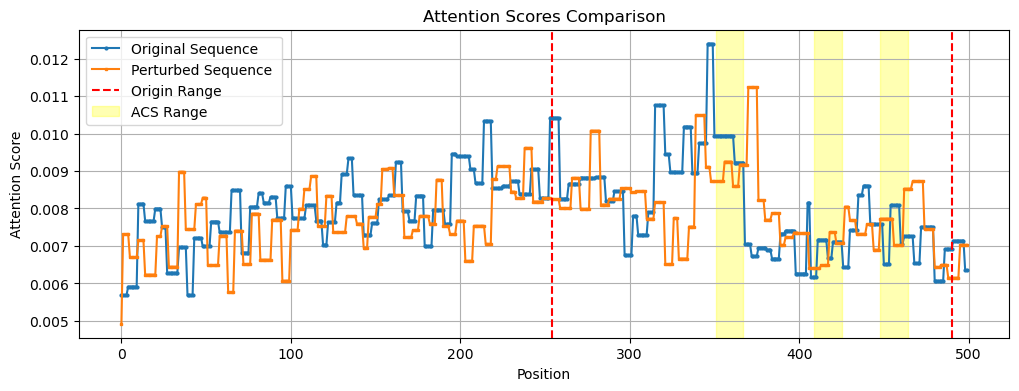

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  27
total len of removed ACSs:  64
original:  [[0.00543783 0.9945622 ]]
removed:  [[0.00544657 0.99455345]]
extended:  [[0.00544946 0.9945505 ]]
original token len:  5.102
removed token len:  4.955
extendedtoken len:  4.95
chr                                                               15
start                                                         783090
end                                                           783589
seq                ACATGAATGAAAATACATCAAATGATGTAGAGAAAGCAAGTGAAGA...
label                                                              1
intersects         [(783297, 783313), (783380, 783396), (783420, ...
updated_seq        ACATGAATGAAAATACATCAAATGATGTAGAGAAAGCAAGTGAAGA...
removed_lengths                                                   64
ex_seq             TGGCAAAGAAGATGGTTCAAACAAGTGGACTAACATGAATGAAAAT...
Name: 27, dtype: object
     chr   start     end         name  length
298   15  783344  783563  1524,00 ARS     220
AATATAAATGTTTTTAA
CGTTTTTATTT

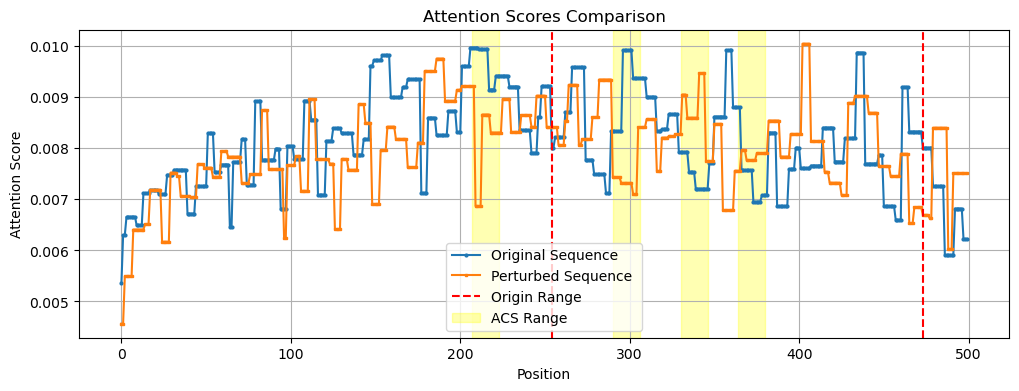

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  28
total len of removed ACSs:  48
original:  [[0.00540514 0.9945949 ]]
removed:  [[0.0054234 0.9945766]]
extended:  [[0.00574836 0.9942516 ]]
original token len:  5.102
removed token len:  5.079
extendedtoken len:  4.95
chr                                                                8
start                                                         245498
end                                                           245997
seq                TACATAACTGGACCGAAGAGTTATTGGGAAAGAAGAAAGAAGCATG...
label                                                              1
intersects         [(245733, 245749), (245788, 245804), (245804, ...
updated_seq        TACATAACTGGACCGAAGAGTTATTGGGAAAGAAGAAAGAAGCATG...
removed_lengths                                                   48
ex_seq             AAGTATCTAAGAATGAATGGAAATTACATAACTGGACCGAAGAGTT...
Name: 28, dtype: object
     chr   start     end        name  length
142    8  245719  245968  813,00 ARS     250
TAATTTTATATTAACAG
CTATTTTATGATTAG

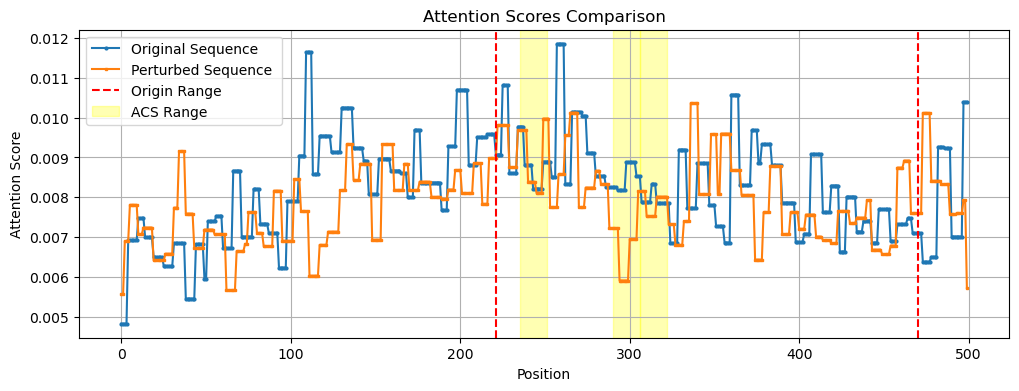

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  30
total len of removed ACSs:  32
original:  [[0.00538374 0.9946163 ]]
removed:  [[0.00541065 0.9945893 ]]
extended:  [[0.00555779 0.99444216]]
original token len:  4.95
removed token len:  4.875
extendedtoken len:  4.854
chr                                                               15
start                                                         729732
end                                                           730231
seq                ATATATCATTGTGCTCACATGTGCTAACATGTGAGCACTCCAAGCT...
label                                                              1
intersects                      [(729795, 729811), (729971, 729987)]
updated_seq        ATATATCATTGTGCTCACATGTGCTAACATGTGAGCACTCCAAGCT...
removed_lengths                                                   32
ex_seq             TCTTTTTTAAAGCGTAATATATCATTGTGCTCACATGTGCTAACAT...
Name: 30, dtype: object
     chr   start     end         name  length
296   15  729739  729969  1521,00 ARS     231
TATTTTTATATTTTGGC
AACATAACGCA

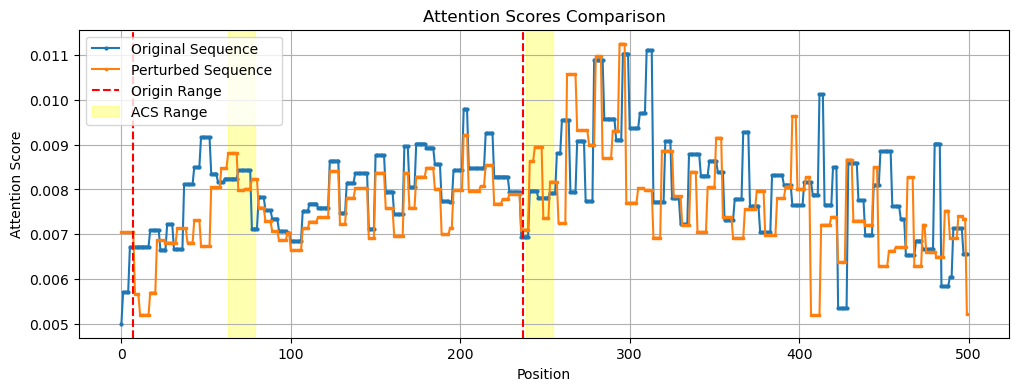

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  31
total len of removed ACSs:  16
original:  [[0.00552899 0.9944711 ]]
removed:  [[0.0055041 0.9944959]]
extended:  [[0.00549448 0.99450547]]
original token len:  5.102
removed token len:  5.095
extendedtoken len:  5.0
chr                                                                6
start                                                         216224
end                                                           216723
seq                TGAATTAAAAACTGCAATGATTGATAATAAAGGTTCATTTTACTTG...
label                                                              1
intersects                                        [(216481, 216497)]
updated_seq        TGAATTAAAAACTGCAATGATTGATAATAAAGGTTCATTTTACTTG...
removed_lengths                                                   16
ex_seq             ATTTGGATTGAATTAAAAACTGCAATGATTGATAATAAAGGTTCAT...
Name: 31, dtype: object
     chr   start     end        name  length
103    6  216344  216692  608,00 ARS     349
TTTTTTTACTTTTAGTT


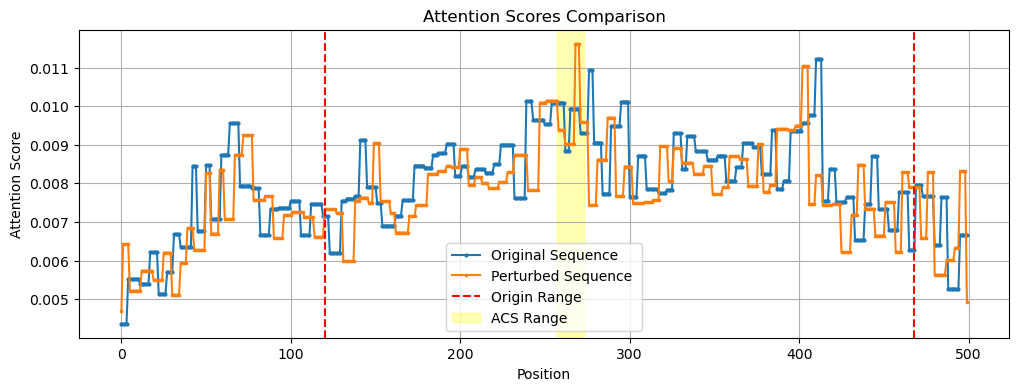

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  32
total len of removed ACSs:  16
original:  [[0.00547284 0.99452716]]
removed:  [[0.00550434 0.9944957 ]]
extended:  [[0.00545392 0.99454606]]
original token len:  4.902
removed token len:  4.889
extendedtoken len:  4.902
chr                                                                9
start                                                          73778
end                                                            74277
seq                TTAAGTACATGAAGGTAGAATATTTCAAATATGATGTCAAAGGCGA...
label                                                              1
intersects                                          [(73907, 73923)]
updated_seq        TTAAGTACATGAAGGTAGAATATTTCAAATATGATGTCAAAGGCGA...
removed_lengths                                                   16
ex_seq             TGGGCGTTTTAAGTACATGAAGGTAGAATATTTCAAATATGATGTC...
Name: 32, dtype: object
     chr  start    end        name  length
152    9  73803  74220  907,00 ARS     418
TTTTTAATTGTTTTTTT


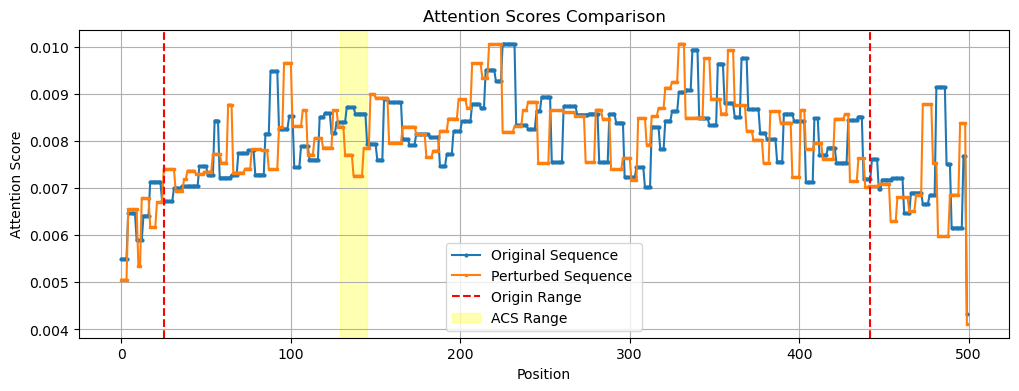

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  33
total len of removed ACSs:  64
original:  [[0.00558059 0.9944194 ]]
removed:  [[0.00550579 0.99449414]]
extended:  [[0.00545836 0.9945417 ]]
original token len:  5.319
removed token len:  5.317
extendedtoken len:  5.208
chr                                                               16
start                                                         331593
end                                                           332092
seq                TAAGACAGCCTCAAAACGCAAATACACCAACTTATGACGATAGTGA...
label                                                              1
intersects         [(331602, 331618), (331756, 331772), (331777, ...
updated_seq        TAAGACAGCACCAACTTATGACGATAGTGATATATCAATGATTTCT...
removed_lengths                                                   64
ex_seq             AAAATTCCCTCCAATACGAAACCGCATCGCATTAAGACAGCACCAA...
Name: 33, dtype: object
     chr   start     end         name  length
308   16  331678  332074  1617,00 ARS     397
CTCAAAACGCAAATACA
CTTTTTTGTA

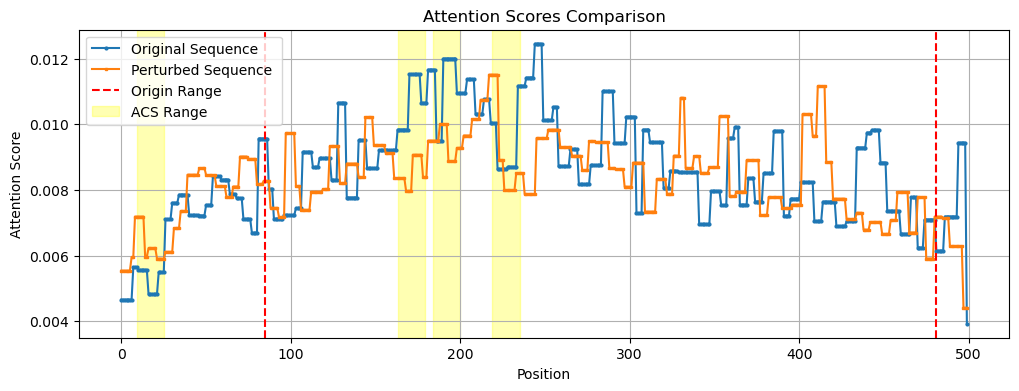

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  34
total len of removed ACSs:  16
original:  [[0.00545641 0.99454355]]
removed:  [[0.00546401 0.99453604]]
extended:  [[0.00543036 0.9945696 ]]
original token len:  5.051
removed token len:  4.99
extendedtoken len:  5.0
chr                                                                7
start                                                         653594
end                                                           654093
seq                TAACTGACTCAGGCGTTTCCTTCATTGAAATGCTCATCTATTGCCA...
label                                                              1
intersects                                        [(653833, 653849)]
updated_seq        TAACTGACTCAGGCGTTTCCTTCATTGAAATGCTCATCTATTGCCA...
removed_lengths                                                   16
ex_seq             TTTTACATTAACTGACTCAGGCGTTTCCTTCATTGAAATGCTCATC...
Name: 34, dtype: object
     chr   start     end        name  length
124    7  653611  654091  726,00 ARS     481
ATCAAAACATAAAAGAA


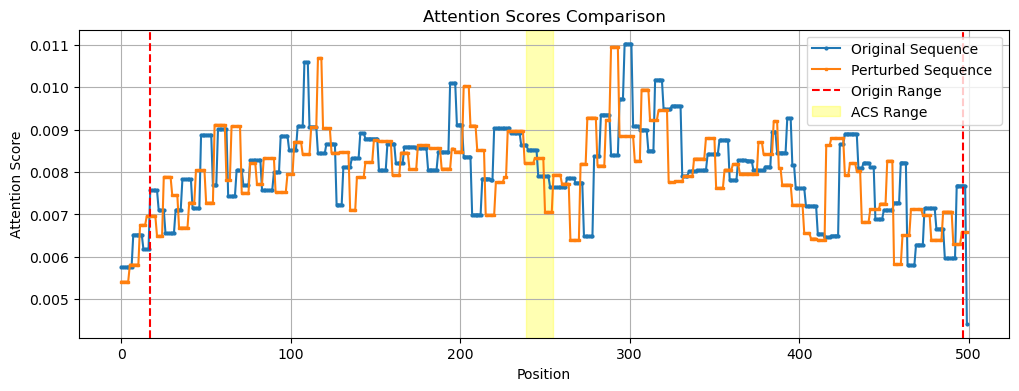

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  35
total len of removed ACSs:  32
original:  [[0.00545174 0.99454826]]
removed:  [[0.0054745  0.99452555]]
extended:  [[0.00575631 0.9942437 ]]
original token len:  5.051
removed token len:  5.087
extendedtoken len:  5.0
chr                                                                7
start                                                          64222
end                                                            64721
seq                GGTTTTGTTTTGCCTGGTTTGGGCCTGACTTTAGTTATATGATTAT...
label                                                              1
intersects                          [(64357, 64373), (64443, 64459)]
updated_seq        GGTTTTGTTTTGCCTGGTTTGGGCCTGACTTTAGTTATATGATTAT...
removed_lengths                                                   32
ex_seq             AATTCCCATTATTATGGGTTTTGTTTTGCCTGGTTTGGGCCTGACT...
Name: 35, dtype: object
     chr  start    end        name  length
107    7  64279  64528  702,00 ARS     250
TATTGTTATATTTAGTT
AACAAAATATTAAAAAT


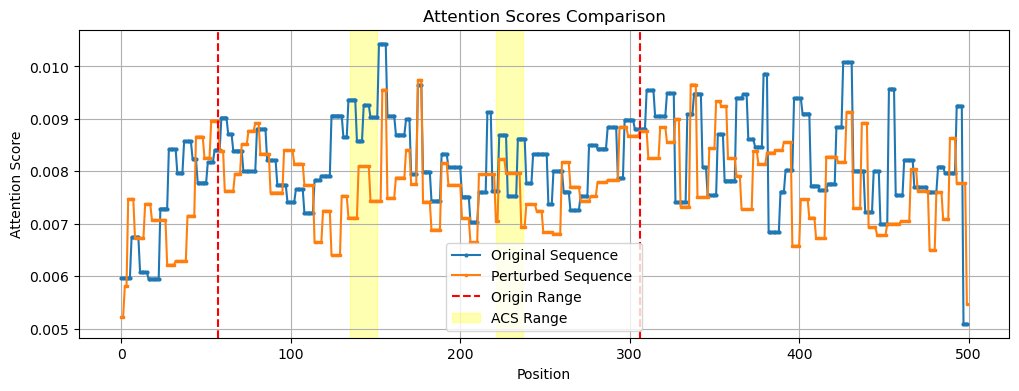

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  36
total len of removed ACSs:  80
original:  [[0.00544147 0.9945585 ]]
removed:  [[0.00544659 0.9945533 ]]
extended:  [[0.00540063 0.99459934]]
original token len:  5.263
removed token len:  5.06
extendedtoken len:  5.0
chr                                                               12
start                                                        1007053
end                                                          1007552
seq                AAGAAATAGCAACAAAATTAGATAAATCTCGGTGGAGTTATCCAAA...
label                                                              1
intersects         [(1007093, 1007109), (1007240, 1007256), (1007...
updated_seq        AAGAAATAGCAACAAAATTAGATAAATCTCGGTGGAGTTATATATC...
removed_lengths                                                   80
ex_seq             ATTATAATTGATAGTGCGCTGCTTTTTTGCACTTCCAGTAAAGAAA...
Name: 36, dtype: object
     chr    start      end         name  length
228   12  1007180  1007470  1232,00 ARS     291
TCCAAAATATGTAATAT
TATTTTTAT

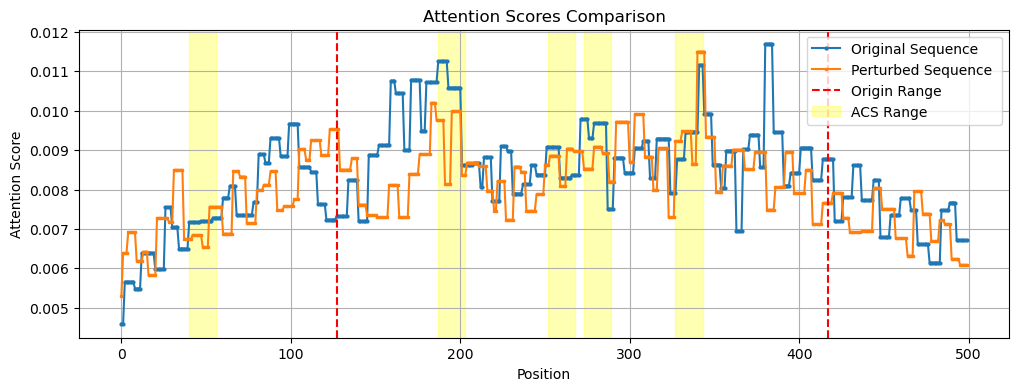

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  37
total len of removed ACSs:  32
original:  [[0.00548909 0.9945109 ]]
removed:  [[0.00550755 0.9944924 ]]
extended:  [[0.00544628 0.9945537 ]]
original token len:  5.435
removed token len:  5.442
extendedtoken len:  5.376
chr                                                                9
start                                                         105737
end                                                           106236
seq                CTTAAAACGTTTATGTGTGTATTTATATATGATAATAATAATAATA...
label                                                              1
intersects                      [(105951, 105967), (106093, 106109)]
updated_seq        CTTAAAACGTTTATGTGTGTATTTATATATGATAATAATAATAATA...
removed_lengths                                                   32
ex_seq             CTTGCTGAACATAAGCCTTAAAACGTTTATGTGTGTATTTATATAT...
Name: 37, dtype: object
     chr   start     end        name  length
154    9  105821  106048  909,00 ARS     228
AAGAAAACATGAATAAT
ACGAAAAAATTA

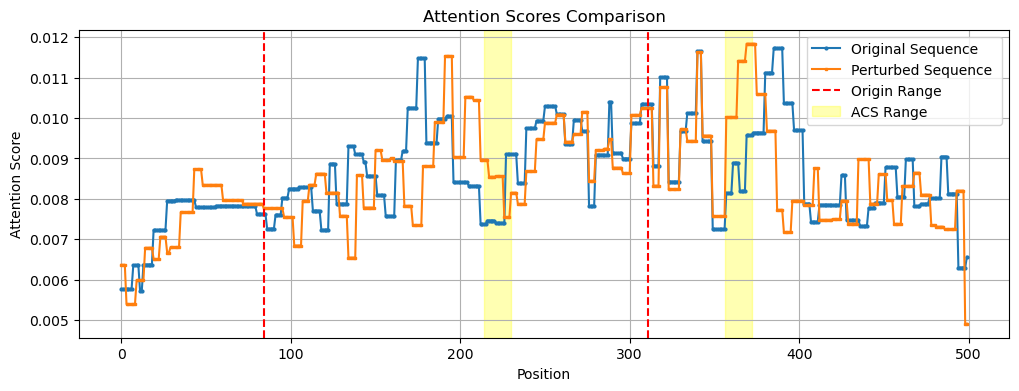

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  38
total len of removed ACSs:  48
original:  [[0.00615129 0.99384874]]
removed:  [[0.00547679 0.99452317]]
extended:  [[0.00556321 0.99443674]]
original token len:  5.102
removed token len:  5.022
extendedtoken len:  5.051
chr                                                               12
start                                                         744837
end                                                           745336
seq                ATAGTTTCTCCTTGAGTCAAGTTCAGAGTAATTTTCGGTTGATTTG...
label                                                              1
intersects         [(745100, 745116), (745137, 745153), (745281, ...
updated_seq        ATAGTTTCTCCTTGAGTCAAGTTCAGAGTAATTTTCGGTTGATTTG...
removed_lengths                                                   48
ex_seq             TTGAACATGTCAAATATGATAACAATAGTTTCTCCTTGAGTCAAGT...
Name: 38, dtype: object
     chr   start     end         name  length
222   12  744942  745179  1223,00 ARS     238
AACAAAACATAAAGATA
AAGAAAACAA

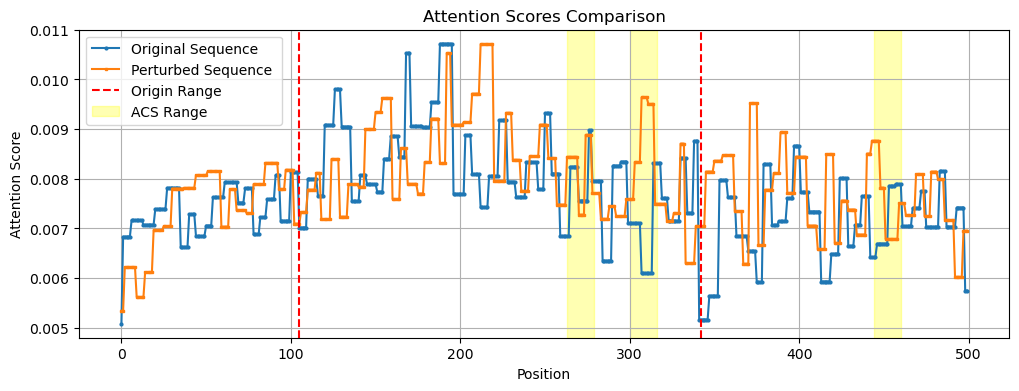

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  39
total len of removed ACSs:  48
original:  [[0.00542266 0.9945773 ]]
removed:  [[0.00539954 0.9946004 ]]
extended:  [[0.00542376 0.9945762 ]]
original token len:  5.051
removed token len:  4.86
extendedtoken len:  4.902
chr                                                                4
start                                                         913724
end                                                           914223
seq                AGCTGACGATCCAGTCAGCGACATCTGTCTTTTTTTAATTACTATT...
label                                                              1
intersects         [(913797, 913813), (913865, 913881), (913942, ...
updated_seq        AGCTGACGATCCAGTCAGCGACATCTGTCTTTTTTTAATTACTATT...
removed_lengths                                                   48
ex_seq             AGGATCAAGGAATACTGAAGTGCAAGCTGACGATCCAGTCAGCGAC...
Name: 39, dtype: object
    chr   start     end        name  length
62    4  913780  914029  428,00 ARS     250
TTATTTTATTTTTAGTA
TATTTTTATATTTTG

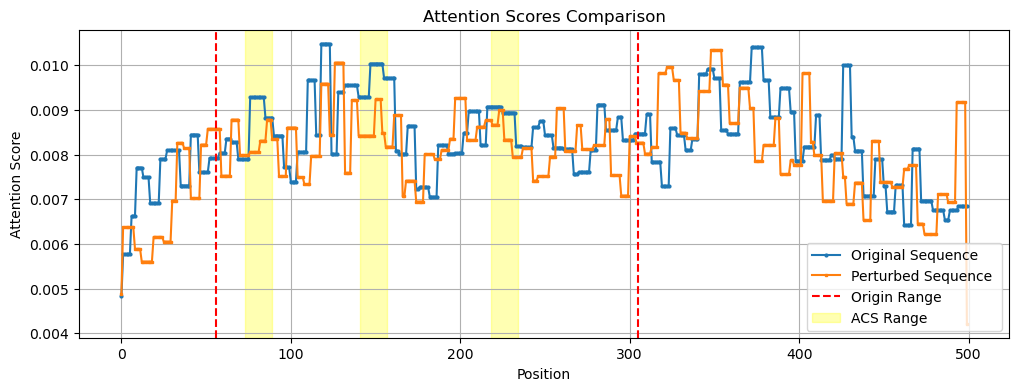

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  41
total len of removed ACSs:  16
original:  [[0.00541911 0.9945809 ]]
removed:  [[0.00543383 0.9945662 ]]
extended:  [[0.00548332 0.9945167 ]]
original token len:  4.902
removed token len:  4.889
extendedtoken len:  4.95
chr                                                                3
start                                                         224719
end                                                           225218
seq                ATACGACCGGTCCTGAGAAAAGAGAAAGGGAACACTTCTAATTTAT...
label                                                              1
intersects                                        [(224861, 224877)]
updated_seq        ATACGACCGGTCCTGAGAAAAGAGAAAGGGAACACTTCTAATTTAT...
removed_lengths                                                   16
ex_seq             CGGAGGGAATACGACCGGTCCTGAGAAAAGAGAAAGGGAACACTTC...
Name: 41, dtype: object
    chr   start     end        name  length
35    3  224807  225053  315,00 ARS     247
TTTTTTTATGTTTTTCT


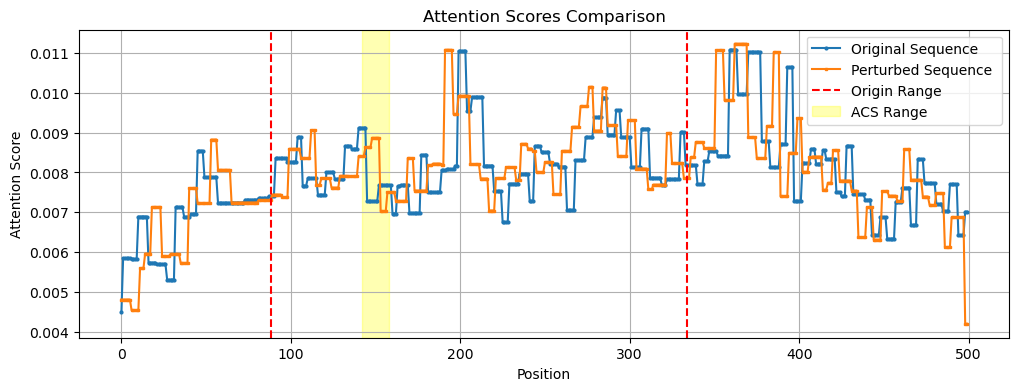

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  42
total len of removed ACSs:  48
original:  [[0.00539619 0.9946038 ]]
removed:  [[0.00540956 0.9945905 ]]
extended:  [[0.00539018 0.99460983]]
original token len:  5.051
removed token len:  4.967
extendedtoken len:  4.95
chr                                                                8
start                                                         391984
end                                                           392483
seq                TGTAGGTAAAAATCTTTGATTTATCTTATCTGGTTGCAATGCTTCT...
label                                                              1
intersects         [(392088, 392104), (392232, 392248), (392281, ...
updated_seq        TGTAGGTAAAAATCTTTGATTTATCTTATCTGGTTGCAATGCTTCT...
removed_lengths                                                   48
ex_seq             AGTATAATAATAGTATAAGTAGTTTGTAGGTAAAAATCTTTGATTT...
Name: 42, dtype: object
     chr   start     end        name  length
144    8  392148  392391  818,00 ARS     244
ATAATTTACATTAATAT
AACAAAACATGAA

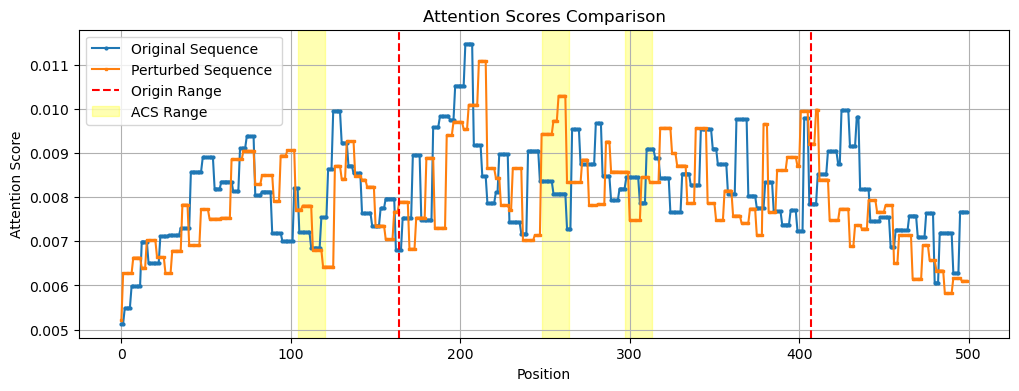

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  43
total len of removed ACSs:  32
original:  [[0.00547035 0.99452966]]
removed:  [[0.00548111 0.99451894]]
extended:  [[0.00615982 0.99384016]]
original token len:  5.102
removed token len:  5.087
extendedtoken len:  5.051
chr                                                                7
start                                                         352680
end                                                           353179
seq                GCTCACCCGTACATATGCTCCTTCTTCACTCATTTTCTTGTCCTGT...
label                                                              1
intersects                      [(352848, 352864), (352947, 352963)]
updated_seq        GCTCACCCGTACATATGCTCCTTCTTCACTCATTTTCTTGTCCTGT...
removed_lengths                                                   32
ex_seq             TTATACAAGAAAAATGGCTCACCCGTACATATGCTCCTTCTTCACT...
Name: 43, dtype: object
     chr   start     end        name  length
116    7  352695  352917  716,00 ARS     223
AACTAAACGTAATTAAA
ATCAAAACAAAT

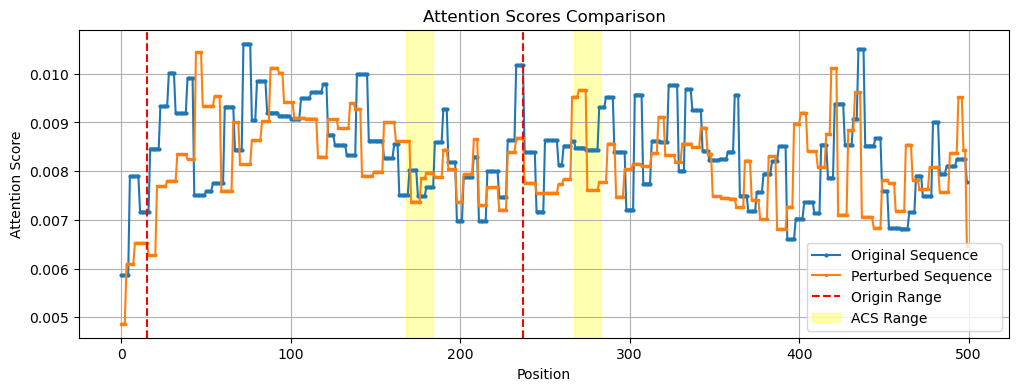

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  44
total len of removed ACSs:  16
original:  [[0.00543662 0.9945634 ]]
removed:  [[0.00545459 0.99454546]]
extended:  [[0.00555826 0.9944417 ]]
original token len:  5.051
removed token len:  4.99
extendedtoken len:  5.0
chr                                                                8
start                                                         168323
end                                                           168822
seq                GCAAATGGCAATTCACTTCTTGGAGTAAAGATCCTCAACTTGTAAT...
label                                                              1
intersects                                        [(168578, 168594)]
updated_seq        GCAAATGGCAATTCACTTCTTGGAGTAAAGATCCTCAACTTGTAAT...
removed_lengths                                                   16
ex_seq             GTGACCAGGCAAATGGCAATTCACTTCTTGGAGTAAAGATCCTCAA...
Name: 44, dtype: object
     chr   start     end        name  length
141    8  168531  168773  809,00 ARS     243
TTTTTTTATCTTATCTT


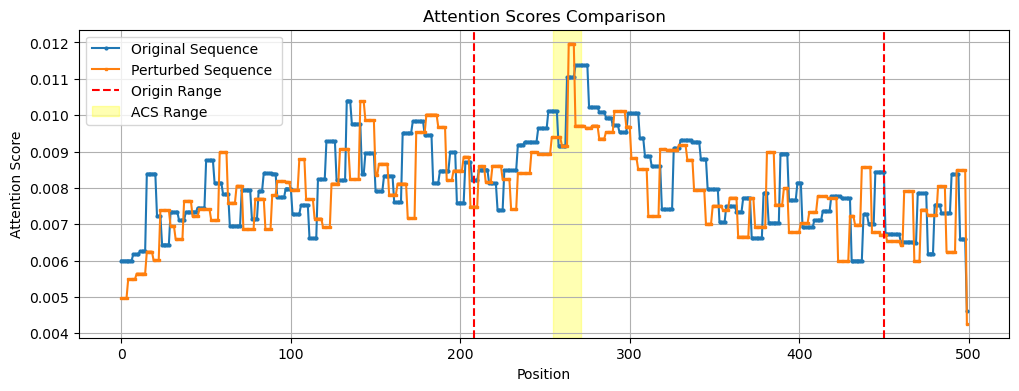

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  45
total len of removed ACSs:  32
original:  [[0.00539974 0.9946003 ]]
removed:  [[0.00541057 0.99458945]]
extended:  [[0.00540341 0.9945966 ]]
original token len:  4.95
removed token len:  4.979
extendedtoken len:  4.95
chr                                                               12
start                                                         450454
end                                                           450953
seq                ATTAGTTTGCCAGGATATACCTTATCCAATTTAGCGTGACGATCTT...
label                                                              1
intersects                      [(450505, 450521), (450644, 450660)]
updated_seq        ATTAGTTTGCCAGGATATACCTTATCCAATTTAGCGTGACGATCTT...
removed_lengths                                                   32
ex_seq             ACTTCTTCAATATCAAATTAGTTTGCCAGGATATACCTTATCCAAT...
Name: 45, dtype: object
     chr   start     end         name  length
214   12  450485  450726  1216,00 ARS     242
CGTTTTTATGTTTATTC
AGCAAGATATAA

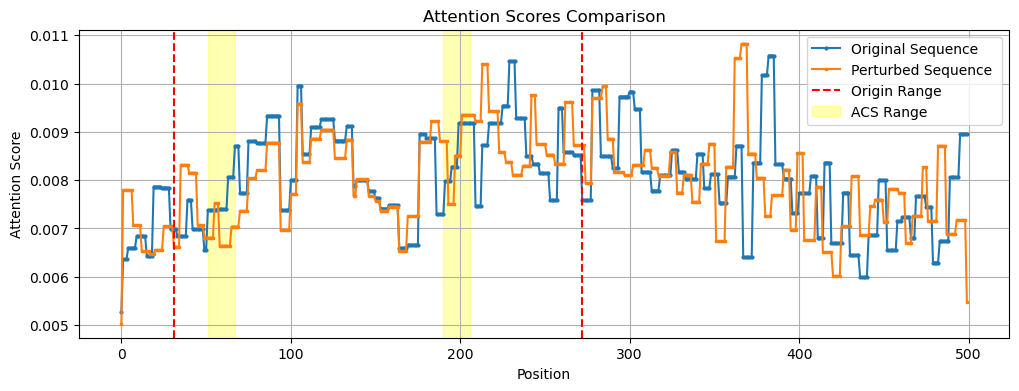

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  46
total len of removed ACSs:  16
original:  [[0.9940923  0.00590775]]
removed:  [[0.99358433 0.00641561]]
extended:  [[0.9937484 0.0062516]]
original token len:  4.854
removed token len:  4.84
extendedtoken len:  4.854
chr                                                                2
start                                                         773883
end                                                           774382
seq                ATAACAATTCGAAATCTCTAAGCTCGCTTATAGTTGACAATGACCA...
label                                                              1
intersects                                        [(774025, 774041)]
updated_seq        ATAACAATTCGAAATCTCTAAGCTCGCTTATAGTTGACAATGACCA...
removed_lengths                                                   16
ex_seq             TTATAACAATAACAATTCGAAATCTCTAAGCTCGCTTATAGTTGAC...
Name: 46, dtype: object
    chr   start     end        name  length
25    2  773918  774348  227,00 ARS     431
TCATAAACATAAAATCC


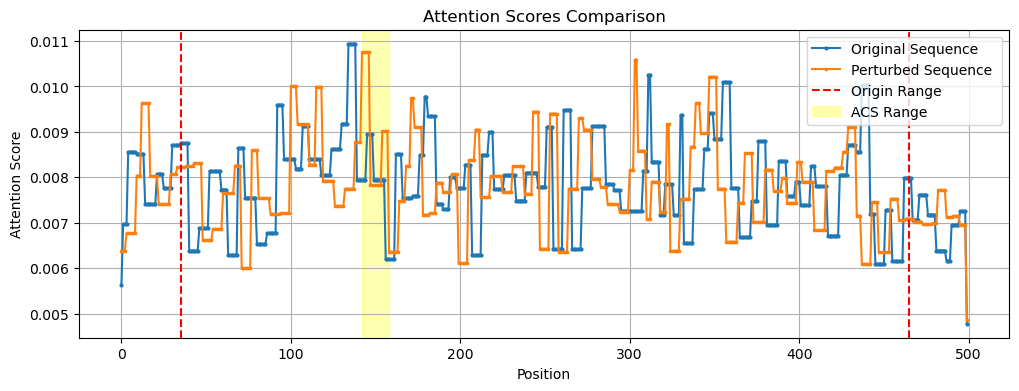

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  47
total len of removed ACSs:  16
original:  [[0.00545595 0.994544  ]]
removed:  [[0.00545984 0.99454015]]
extended:  [[0.00543395 0.9945661 ]]
original token len:  5.376
removed token len:  5.319
extendedtoken len:  5.263
chr                                                                5
start                                                         406620
end                                                           407119
seq                TCCTTTATCAAAAGACTACACGCACATATATATTAATCCCGGTATG...
label                                                              1
intersects                                        [(406891, 406907)]
updated_seq        TCCTTTATCAAAAGACTACACGCACATATATATTAATCCCGGTATG...
removed_lengths                                                   16
ex_seq             TGTATATTTCCTTTATCAAAAGACTACACGCACATATATATTAATC...
Name: 47, dtype: object
    chr   start     end        name  length
91    5  406747  406949  517,00 ARS     203
GACTATATATAAAAAAA


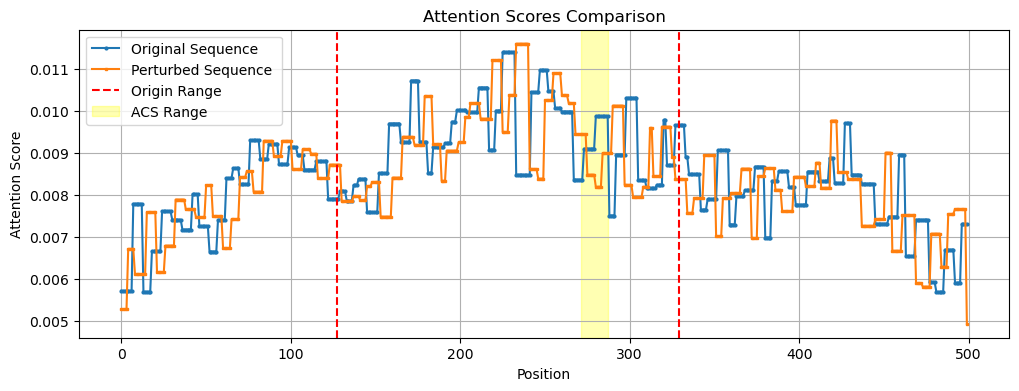

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  48
total len of removed ACSs:  16
original:  [[0.00539744 0.9946025 ]]
removed:  [[0.00540253 0.99459743]]
extended:  [[0.00540268 0.9945973 ]]
original token len:  5.208
removed token len:  5.204
extendedtoken len:  5.208
chr                                                                1
start                                                         175911
end                                                           176410
seq                AACGATATTCGATAATGCGCCAAGCCTTTATAAGGAACTCAAAATA...
label                                                              1
intersects                                        [(176234, 176250)]
updated_seq        AACGATATTCGATAATGCGCCAAGCCTTTATAAGGAACTCAAAATA...
removed_lengths                                                   16
ex_seq             TTTACTAAAACGATATTCGATAATGCGCCAAGCCTTTATAAGGAAC...
Name: 48, dtype: object
   chr   start     end        name  length
4    1  176154  176402  110,00 ARS     249
TCTTTTTATGTTTTCTT


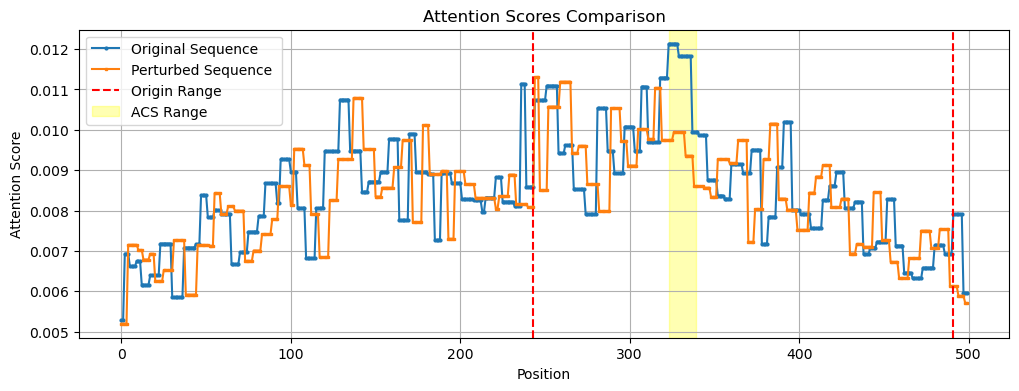

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  49
total len of removed ACSs:  32
original:  [[0.00558753 0.9944125 ]]
removed:  [[0.00562102 0.994379  ]]
extended:  [[0.00562509 0.9943749 ]]
original token len:  5.0
removed token len:  4.979
extendedtoken len:  5.0
chr                                                                9
start                                                         174945
end                                                           175444
seq                TAGAAGCAGTCGAGTACGAATCACTGTGACCGTCATCCTAGATAAA...
label                                                              1
intersects                      [(175173, 175189), (175303, 175319)]
updated_seq        TAGAAGCAGTCGAGTACGAATCACTGTGACCGTCATCCTAGATAAA...
removed_lengths                                                   32
ex_seq             GCCACCTACAGATTATTAGAAGCAGTCGAGTACGAATCACTGTGAC...
Name: 49, dtype: object
     chr   start     end        name  length
157    9  175034  175355  912,00 ARS     322
ATGTTTTATGTTTTGTC
ATTTTTATTGTTTTGA

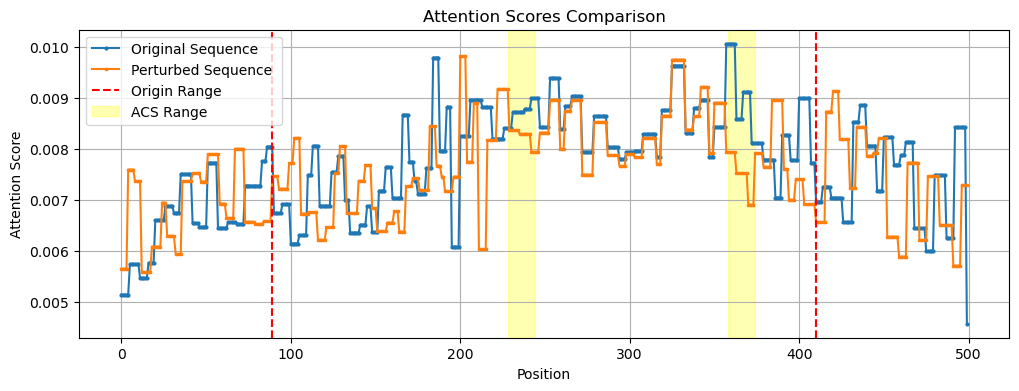

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  50
total len of removed ACSs:  32
original:  [[0.00541483 0.9945852 ]]
removed:  [[0.00540767 0.99459237]]
extended:  [[0.00542699 0.99457306]]
original token len:  5.102
removed token len:  5.087
extendedtoken len:  5.0
chr                                                                4
start                                                         639744
end                                                           640243
seq                GAGACCATGTTCTGCAACATTTAAATAAAAAAATTCCATGCACTCA...
label                                                              1
intersects                      [(639762, 639778), (640053, 640069)]
updated_seq        GAGACCATGTTCTGCAACTCCATGCACTCAAGAAATGGAAAATACT...
removed_lengths                                                   32
ex_seq             AAAGATTCAAGAGAAGGAGACCATGTTCTGCAACTCCATGCACTCA...
Name: 50, dtype: object
    chr   start     end        name  length
57    4  639859  640108  421,00 ARS     250
ATTTAAATAAAAAAATT
ACCAAAACTTTAAAAA

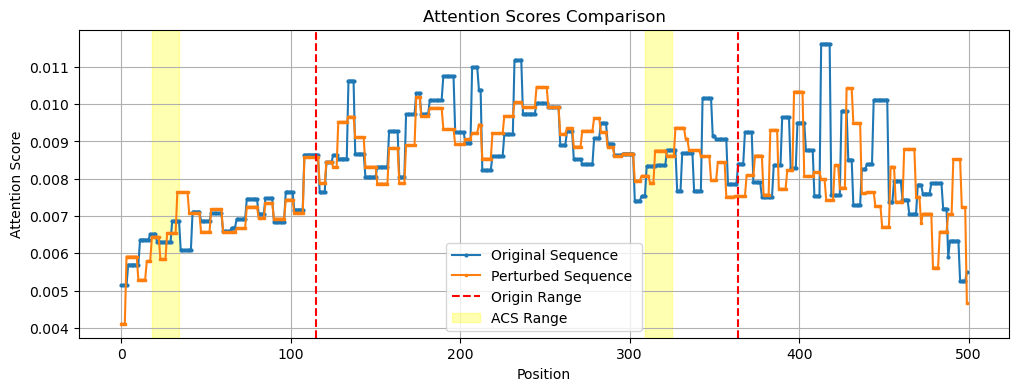

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  51
total len of removed ACSs:  32
original:  [[0.0054138 0.9945862]]
removed:  [[0.00540273 0.9945972 ]]
extended:  [[0.00541892 0.99458104]]
original token len:  5.0
removed token len:  4.979
extendedtoken len:  5.051
chr                                                               15
start                                                          35529
end                                                            36028
seq                TGCAAACTTTGACGAGAATGTACTGCTCATTATTTTTCGTAAACTG...
label                                                              1
intersects                          [(35714, 35730), (35835, 35851)]
updated_seq        TGCAAACTTTGACGAGAATGTACTGCTCATTATTTTTCGTAAACTG...
removed_lengths                                                   32
ex_seq             TATTTTTTATATGATTTGCAAACTTTGACGAGAATGTACTGCTCAT...
Name: 51, dtype: object
     chr  start    end       name  length
279   15  35667  35903  ARS1506.5     237
TATATTTATATTTAGAG
TACAAAATGAAACATAA


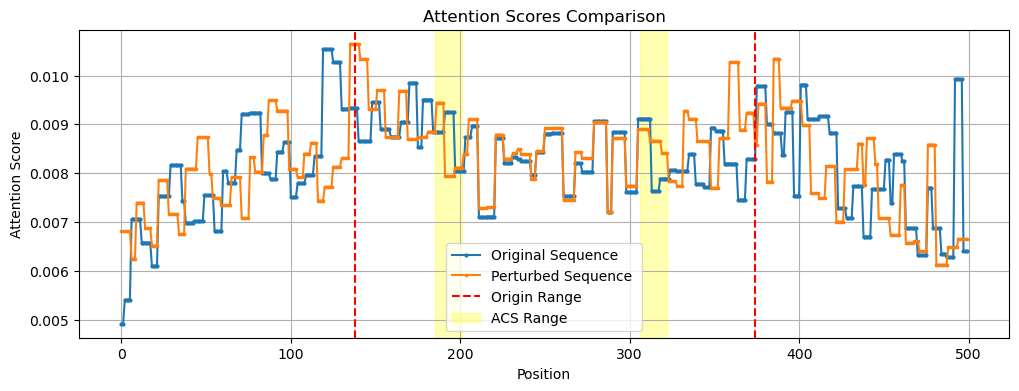

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  52
total len of removed ACSs:  32
original:  [[0.00542124 0.9945787 ]]
removed:  [[0.00541922 0.9945808 ]]
extended:  [[0.00543035 0.9945696 ]]
original token len:  5.0
removed token len:  4.926
extendedtoken len:  4.902
chr                                                               13
start                                                         535438
end                                                           535937
seq                CGTGAAACCAAACATAGTTTAACTCCCTATAGCTCCATTTGATAAG...
label                                                              1
intersects                      [(535662, 535678), (535755, 535771)]
updated_seq        CGTGAAACCAAACATAGTTTAACTCCCTATAGCTCCATTTGATAAG...
removed_lengths                                                   32
ex_seq             TTGAGTACTTATCCGCCGTGAAACCAAACATAGTTTAACTCCCTAT...
Name: 52, dtype: object
     chr   start     end         name  length
245   13  535595  535843  1320,00 ARS     249
AGTTGTTTTGTTTTTTT
AACTAAATATAA

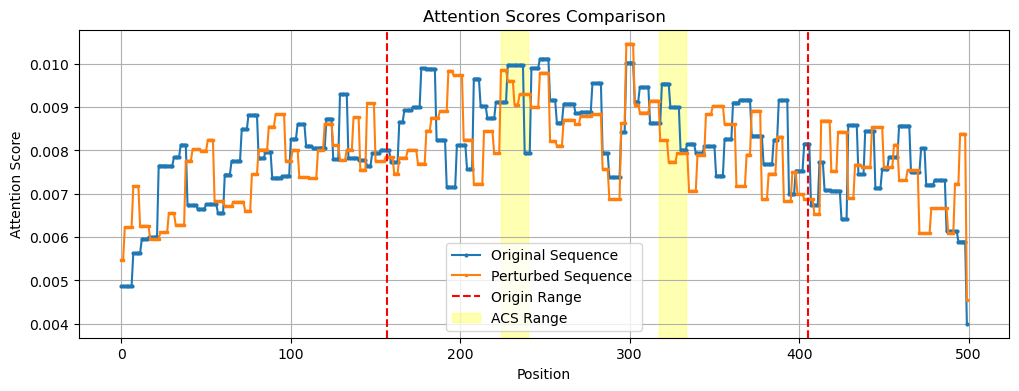

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  53
total len of removed ACSs:  32
original:  [[0.00543491 0.9945651 ]]
removed:  [[0.00544536 0.99455464]]
extended:  [[0.00551454 0.99448544]]
original token len:  5.0
removed token len:  4.926
extendedtoken len:  4.808
chr                                                                8
start                                                         535393
end                                                           535892
seq                TACTCATTGGTGTGTGTCAAAAACAGTACGTTTATTATCTGGACAG...
label                                                              1
intersects                      [(535623, 535639), (535749, 535765)]
updated_seq        TACTCATTGGTGTGTGTCAAAAACAGTACGTTTATTATCTGGACAG...
removed_lengths                                                   32
ex_seq             AGTCGCAATAACGTCTTACTCATTGGTGTGTGTCAAAAACAGTACG...
Name: 53, dtype: object
     chr   start     end      name  length
149    8  535403  535836  ARS823.5     434
AACTAAATATTAAAATG
TTCTAAACATGAATAAT


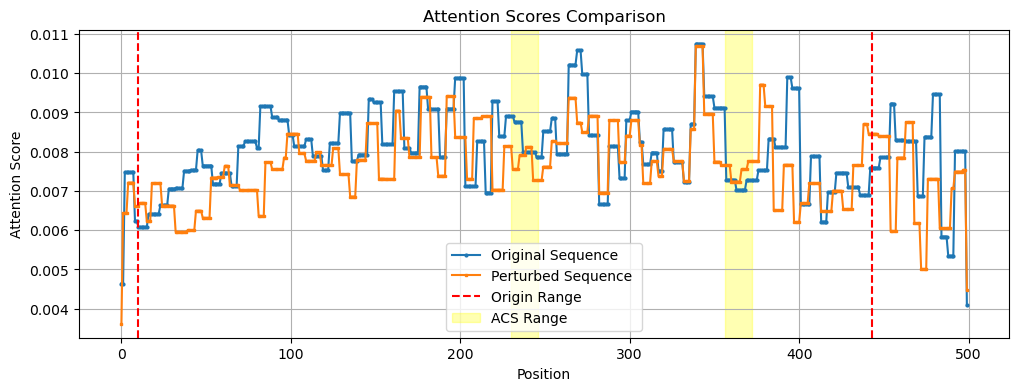

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


seq index:  54
total len of removed ACSs:  89
original:  [[0.00543524 0.9945648 ]]
removed:  [[0.00543054 0.9945695 ]]
extended:  [[0.00541081 0.9945892 ]]
original token len:  4.902
removed token len:  4.724
extendedtoken len:  4.708
chr                                                               16
start                                                         633839
end                                                           634338
seq                TTACTTTCATGGAACACTTAGTAAAAATAACTTAGAAAGGTCGTCT...
label                                                              1
intersects         [(633926, 633942), (633980, 633996), (633989, ...
updated_seq        TTACTTTCATGGAACACTTAGTAAAAATAACTTAGAAAGGTCGTCT...
removed_lengths                                                   89
ex_seq             GTATGTATTTTTATGCTATTCTTGTAAAAGTTTGGCTTATTATTTT...
Name: 54, dtype: object
     chr   start     end         name  length
316   16  633868  634117  1623,00 ARS     250


ValueError: x and y must have same first dimension, but have shapes (500,) and (499,)

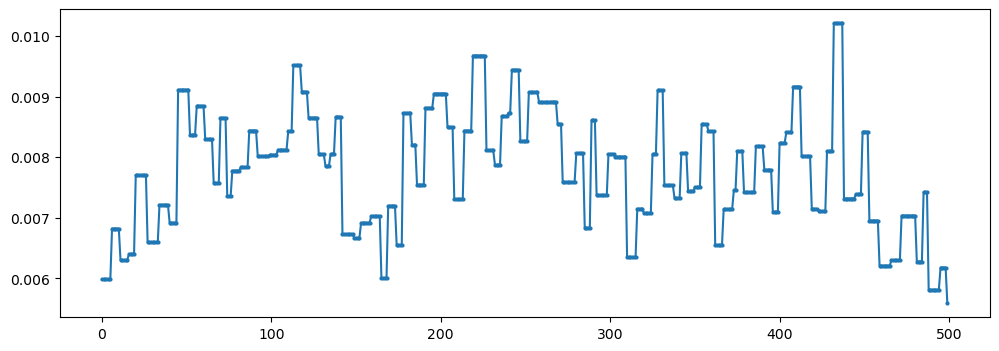

In [ ]:
# visualize all samples
import ast
model_path = "/p/project/hai_dnaori/piroozeh1/yeast-origins/data/OriDB_random_neg/train_dev_test_oridb/DNABERT2/model2"
original_origin=pd.read_csv("/p/project1/hai_dnaori/piroozeh1/yeast-origins/data/yeast_oridbLess500.csv") 

for index, row in df.iterrows():
    if index not in list_index:
        prob, atten, avrg_token_len=inference_model( model_path, row["seq"])
        prob_removed, atten_rmv, avrg_token_len2=inference_model( model_path, row["updated_seq"])
        prob_extended, atten_ex, avrg_token_len3=inference_model( model_path, row["ex_seq"])
        

        print("seq index: ", index)
        print("total len of removed ACSs: ", row["removed_lengths"])
        print("original: ", prob)
        print("removed: ", prob_removed)
        print("extended: ", prob_extended)
        print("original token len: ", round(avrg_token_len,3))
        print("removed token len: ", round(avrg_token_len2,3))
        print("extendedtoken len: ", round(avrg_token_len3,3))
        matching_rows = original_origin[(original_origin['chr'] == row['chr']) & (original_origin['start'] >= row['start']) & (original_origin['end'] <= row['end'])]
        print(row)
        print(matching_rows)
        if not matching_rows.empty:
            origin_start=matching_rows['start'].values[0]
            origin_end=matching_rows['end'].values[0]
            intersects = row['intersects']
            list_of_tuples = ast.literal_eval(intersects)
            # print(type(list_of_tuples[0]))
        visualize(atten, atten_ex, origin_start, origin_end, row['start'], list_of_tuples, row['seq'])
